#와인 품질 예측 모델

In [ ]:
install.packages("caret")
install.packages(c("rattle", "rpart.plot"))
install.packages(c("psych", "pastecs"))
install.packages("showtext")
install.packages("gridExtra")
#--------------------------------------------
library("caret")
library("tidyverse")
library("data.table")
library("repr") # 출력 그래프 크기 변경
library("psych")
library("pastecs")
library("rattle")
library("rpart.plot")
library("RColorBrewer")
library("dplyr")
library("ggplot2")
library("showtext")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bitops’, ‘XML’


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘mnormt’, ‘GPArotation’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘sysfonts’, ‘showtextdb’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: ggplot2

Loading required package: lattice

── Attaching core tidyver

##1.데이터 파일 준비

In [ ]:
#https://drive.google.com/file/d/1IZWfTL4Hyc_PZjScJQZwq1ssGLXd3N6q/view?usp=drive_link

system("gdown --id 1IZWfTL4Hyc_PZjScJQZwq1ssGLXd3N6q")
system("ls", TRUE)


[1] "sample_data"      "wine_quality.csv"

In [ ]:
wine_quality <- fread("/content/wine_quality.csv", header = T, encoding = "UTF-8") %>% as_tibble
wine_quality %>% show()

# A tibble: 6,497 × 13
   type  `fixed acidity` `volatile acidity` `citric acid` `residual sugar`
   <chr>           <dbl>              <dbl>         <dbl>            <dbl>
 1 white             7                 0.27          0.36             20.7
 2 white             6.3               0.3           0.34              1.6
 3 white             8.1               0.28          0.4               6.9
 4 white             7.2               0.23          0.32              8.5
 5 white             7.2               0.23          0.32              8.5
 6 white             8.1               0.28          0.4               6.9
 7 white             6.2               0.32          0.16              7  
 8 white             7                 0.27          0.36             20.7
 9 white             6.3               0.3           0.34              1.6
10 white             8.1               0.22          0.43              1.5
# ℹ 6,487 more rows
# ℹ 8 more variables: chlorides <dbl>, `free sulfur dioxi

In [ ]:
# 1. 한글 폰트 설치
system("apt-get -y install fonts-nanum")  # 나눔 폰트 설치
system("fc-cache -fv")  # 폰트 캐시 초기화

# 2. showtext 패키지 설정
if (!require("showtext")) install.packages("showtext")
library(showtext)

# 3. 나눔고딕 폰트 추가
font_add("NanumGothic", regular = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
showtext_auto()

In [ ]:
# 와인 품질 데이터 변수명 확인
wine_quality %>% names()
cat("\n")

# 행의 수 열의 수 반환
cat("행의 수 : ", nrow(wine_quality ),"\n") # 행 수 반환
cat("열의 수 : ", ncol(wine_quality )) # 열 수 반환

[1] "type"                 "fixed acidity"        "volatile acidity"    
 [4] "citric acid"          "residual sugar"       "chlorides"           
 [7] "free sulfur dioxide"  "total sulfur dioxide" "density"             
[10] "pH"                   "sulphates"            "alcohol"             
[13] "quality"


행의 수 :  6497 
열의 수 :  13

In [ ]:
# 와인 품질 데이터 자료형 확인
wine_quality %>% str()
cat("\n")

# type은 char
# quality는 int
# 나머지 변수들은 num

tibble [6,497 × 13] (S3: tbl_df/tbl/data.frame)
 $ type                : chr [1:6497] "white" "white" "white" "white" ...
 $ fixed acidity       : num [1:6497] 7 6.3 8.1 7.2 7.2 8.1 6.2 7 6.3 8.1 ...
 $ volatile acidity    : num [1:6497] 0.27 0.3 0.28 0.23 0.23 0.28 0.32 0.27 0.3 0.22 ...
 $ citric acid         : num [1:6497] 0.36 0.34 0.4 0.32 0.32 0.4 0.16 0.36 0.34 0.43 ...
 $ residual sugar      : num [1:6497] 20.7 1.6 6.9 8.5 8.5 6.9 7 20.7 1.6 1.5 ...
 $ chlorides           : num [1:6497] 0.045 0.049 0.05 0.058 0.058 0.05 0.045 0.045 0.049 0.044 ...
 $ free sulfur dioxide : num [1:6497] 45 14 30 47 47 30 30 45 14 28 ...
 $ total sulfur dioxide: num [1:6497] 170 132 97 186 186 97 136 170 132 129 ...
 $ density             : num [1:6497] 1.001 0.994 0.995 0.996 0.996 ...
 $ pH                  : num [1:6497] 3 3.3 3.26 3.19 3.19 3.26 3.18 3 3.3 3.22 ...
 $ sulphates           : num [1:6497] 0.45 0.49 0.44 0.4 0.4 0.44 0.47 0.45 0.49 0.45 ...
 $ alcohol             : num [1:6497] 8.

##2. 데이터 정제
###결측값 이상값 확인
###변수명 변경

In [ ]:
# 결측값 확인
wine_na <- sum(is.na(wine_quality))
wine_na %>% show()

# 결측값 존재하지 않음

[1] 0


In [ ]:
summary(wine_quality)

     type           fixed acidity    volatile acidity  citric acid    
 Length:6497        Min.   : 3.800   Min.   :0.0800   Min.   :0.0000  
 Class :character   1st Qu.: 6.400   1st Qu.:0.2300   1st Qu.:0.2500  
 Mode  :character   Median : 7.000   Median :0.2900   Median :0.3100  
                    Mean   : 7.215   Mean   :0.3397   Mean   :0.3186  
                    3rd Qu.: 7.700   3rd Qu.:0.4000   3rd Qu.:0.3900  
                    Max.   :15.900   Max.   :1.5800   Max.   :1.6600  
 residual sugar     chlorides       free sulfur dioxide total sulfur dioxide
 Min.   : 0.600   Min.   :0.00900   Min.   :  1.00      Min.   :  6.0       
 1st Qu.: 1.800   1st Qu.:0.03800   1st Qu.: 17.00      1st Qu.: 77.0       
 Median : 3.000   Median :0.04700   Median : 29.00      Median :118.0       
 Mean   : 5.443   Mean   :0.05603   Mean   : 30.53      Mean   :115.7       
 3rd Qu.: 8.100   3rd Qu.:0.06500   3rd Qu.: 41.00      3rd Qu.:156.0       
 Max.   :65.800   Max.   :0.61100   Max. 

##3. 데이터 가공
###변수 변환 및 전처리


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




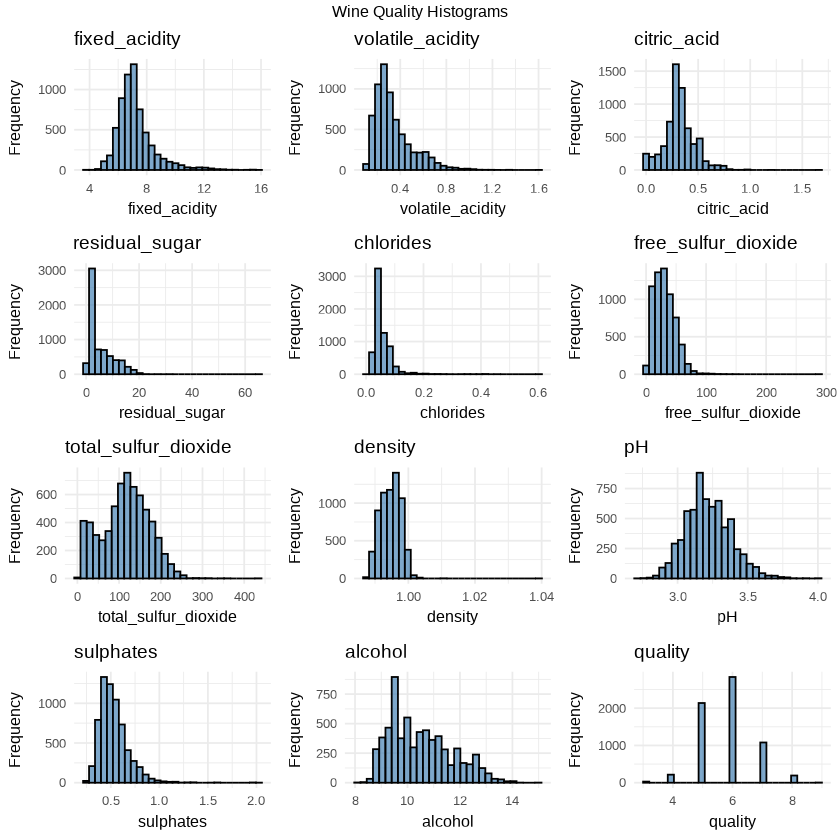

In [ ]:
# 필요한 라이브러리 로드
library(ggplot2)
library(gridExtra)
library(dplyr)  # select 함수 충돌 방지

# 변수명 공백을 언더스코어(_)로 대체
names(wine_quality) <- gsub(" ", "_", names(wine_quality))

# 숫자형 변수 선택
numeric_vars <- names(wine_quality)[sapply(wine_quality, is.numeric)]

# 히스토그램 저장할 리스트 생성
plots <- list()

for (var in numeric_vars) {
  p <- ggplot(wine_quality, aes(x = .data[[var]])) +  # aes()와 tidy eval 사용
    geom_histogram(bins = 30, fill = "steelblue", color = "black", alpha = 0.7) +
    labs(title = var, x = var, y = "Frequency") +
    theme_minimal() +
    theme(
      plot.title = element_text(size = 14),  # 제목 크기 조정
      axis.title = element_text(size = 12), # 축 제목 크기 조정
      axis.text = element_text(size = 10)   # 축 값 크기 조정
    )
  plots[[var]] <- p
}

# 그래프 크기 조정 및 레이아웃 변경
do.call(grid.arrange, c(plots, ncol = 3, top = "Wine Quality Histograms"))


In [ ]:
# 데이터 지표 확인

wine_quality %>% select_if(is.numeric) %>% describe() %>% round(2)

,vars,n,mean,sd,median,trimmed,mad,min,max,range,skew,kurtosis,se
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fixed_acidity,1,6497,7.22,1.30,7.00,7.06,0.89,3.80,15.90,12.10,1.72,5.05,0.02
volatile_acidity,2,6497,0.34,0.16,0.29,0.32,0.12,0.08,1.58,1.50,1.49,2.82,0.00
citric_acid,3,6497,0.32,0.15,0.31,0.32,0.10,0.00,1.66,1.66,0.47,2.39,0.00
residual_sugar,4,6497,5.44,4.76,3.00,4.70,2.52,0.60,65.80,65.20,1.43,4.35,0.06
chlorides,5,6497,0.06,0.04,0.05,0.05,0.02,0.01,0.61,0.60,5.40,50.84,0.00
free_sulfur_dioxide,6,6497,30.53,17.75,29.00,29.32,17.79,1.00,289.00,288.00,1.22,7.90,0.22
total_sulfur_dioxide,7,6497,115.74,56.52,118.00,115.92,57.82,6.00,440.00,434.00,0.00,-0.37,0.70
density,8,6497,0.99,0.00,0.99,0.99,0.00,0.99,1.04,0.05,0.50,6.60,0.00
pH,9,6497,3.22,0.16,3.21,3.21,0.16,2.72,4.01,1.29,0.39,0.37,0.00


In [ ]:
# type factor 변환
wine_quality$type <- as.factor(wine_quality$type)

str(wine_quality$type)

 Factor w/ 2 levels "red","white": 2 2 2 2 2 2 2 2 2 2 ...


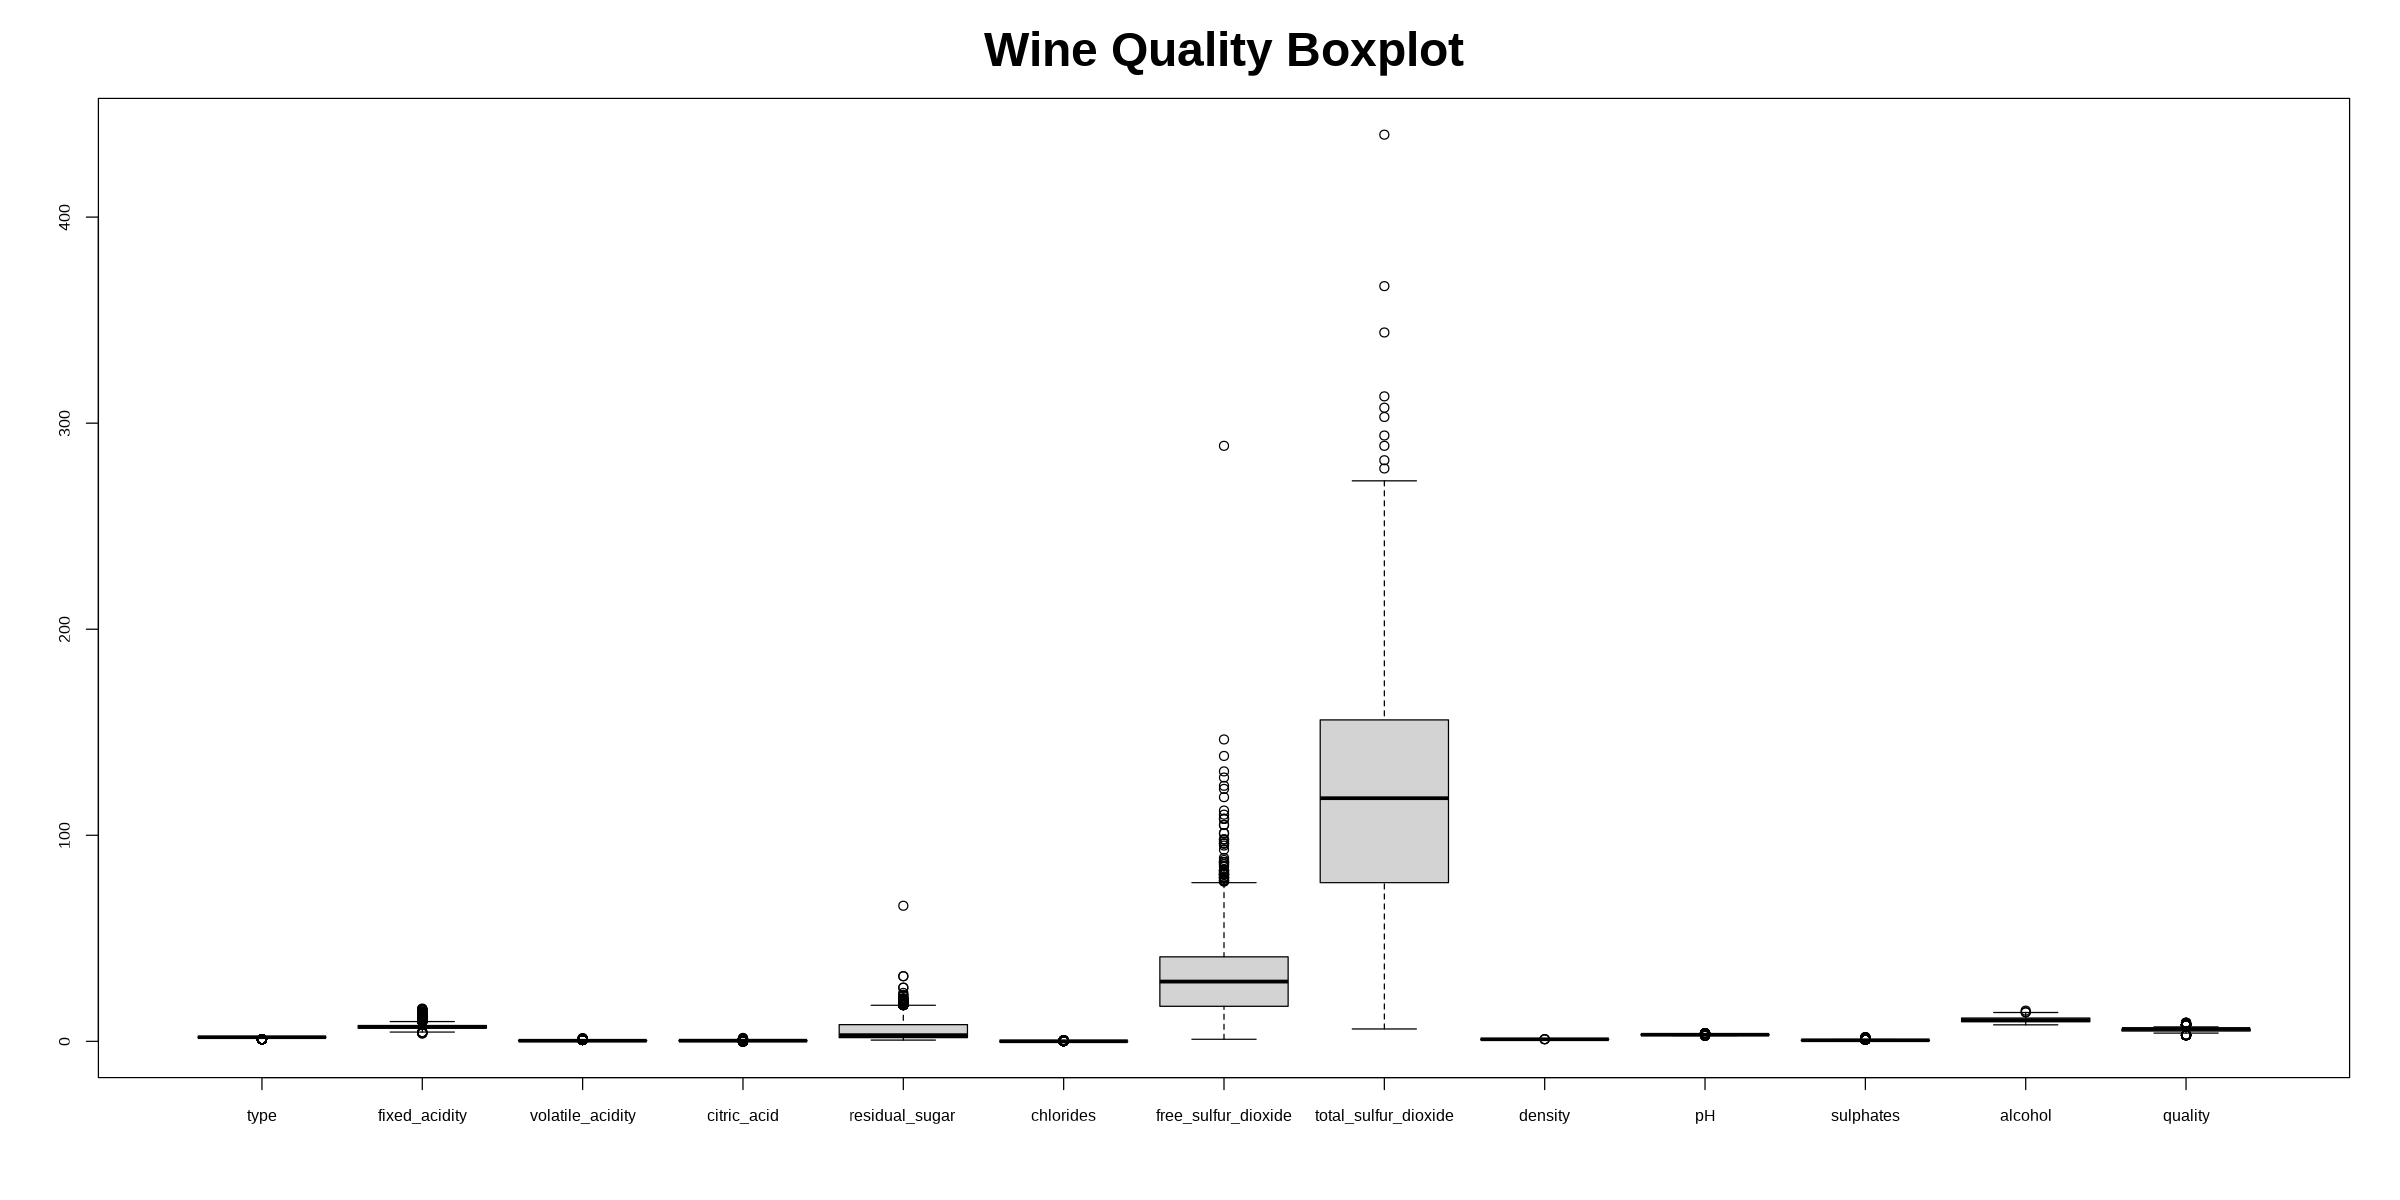

In [ ]:
options(repr.plot.width=20, repr.plot.height=10)  # (가로, 세로) 단위는 inches
boxplot(wine_quality,
        main="Wine Quality Boxplot",
        cex.main=3,     # 제목 폰트 크기
        cex.lab=1.5,    # 축 레이블 폰트 크기
        cex.axis=1)   # 축 눈금 폰트 크기

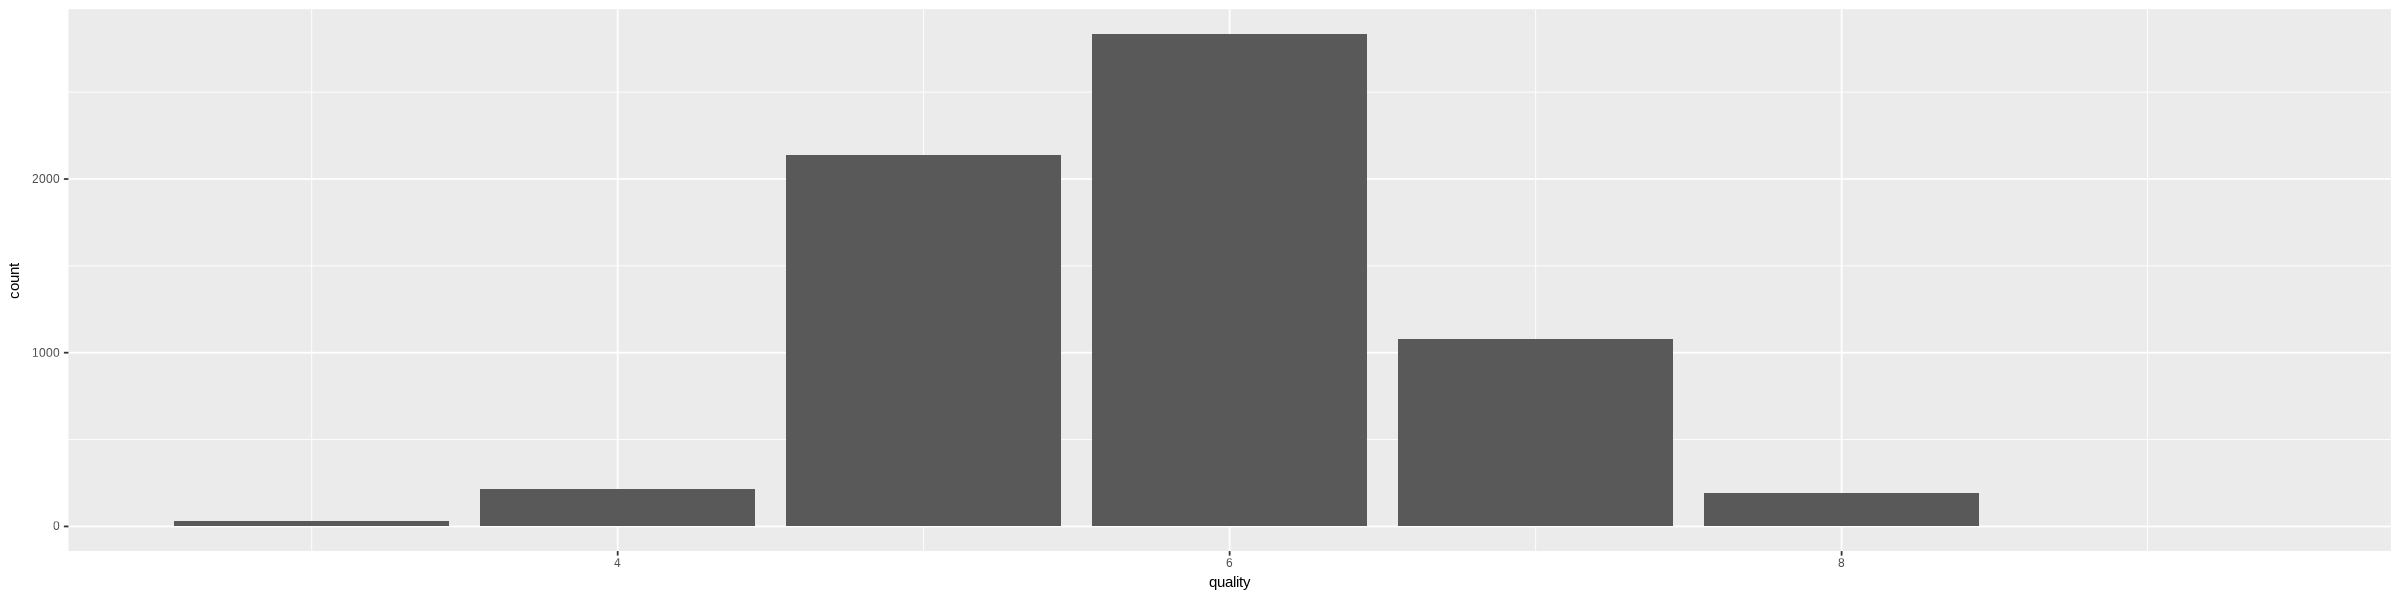

In [ ]:
options(repr.plot.width=20, repr.plot.height=5)
ggplot(wine_quality, aes(x = quality)) + geom_bar(stat = 'count')

Quality는 연속형 데이터이므로 범주형 데이터로 변환하여 분석 성능을 높이기 위해서 범위를 다음과 같이 설정하였습니다.

**0 ~ 5(기본품질) : 0 / 6 ~ 10(우수품질) : 1**

In [ ]:
# wine_quality에서 quality 부분만 선택 new_wine_quality
new_wine_quality <- select(wine_quality, quality)
new_wine_quality %>% show()

# A tibble: 6,497 × 1
   quality
     <int>
 1       6
 2       6
 3       6
 4       6
 5       6
 6       6
 7       6
 8       6
 9       6
10       6
# ℹ 6,487 more rows


In [ ]:
# 0 ~ 5(기본품질) : 0 / 6 ~ 10(우수품질) : 1 로 구분
quality_target <- new_wine_quality %>%
  mutate(new_wine_quality = ifelse(quality < 6, "기본품질", ifelse (quality >= 6 | quality <= 10, "우수품질")))
quality_target %>% show()

# A tibble: 6,497 × 2
   quality new_wine_quality
     <int> <chr>           
 1       6 우수품질        
 2       6 우수품질        
 3       6 우수품질        
 4       6 우수품질        
 5       6 우수품질        
 6       6 우수품질        
 7       6 우수품질        
 8       6 우수품질        
 9       6 우수품질        
10       6 우수품질        
# ℹ 6,487 more rows


In [ ]:
# factor로 변환
wine_quality$quality_target <- factor(quality_target$new_wine_quality)
wine_quality

type,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,quality_target
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<fct>
white,7.0,0.27,0.36,20.70,0.045,45,170,1.0010,3.00,0.45,8.8,6,우수품질
white,6.3,0.30,0.34,1.60,0.049,14,132,0.9940,3.30,0.49,9.5,6,우수품질
white,8.1,0.28,0.40,6.90,0.050,30,97,0.9951,3.26,0.44,10.1,6,우수품질
white,7.2,0.23,0.32,8.50,0.058,47,186,0.9956,3.19,0.40,9.9,6,우수품질
white,7.2,0.23,0.32,8.50,0.058,47,186,0.9956,3.19,0.40,9.9,6,우수품질
white,8.1,0.28,0.40,6.90,0.050,30,97,0.9951,3.26,0.44,10.1,6,우수품질
white,6.2,0.32,0.16,7.00,0.045,30,136,0.9949,3.18,0.47,9.6,6,우수품질
white,7.0,0.27,0.36,20.70,0.045,45,170,1.0010,3.00,0.45,8.8,6,우수품질
white,6.3,0.30,0.34,1.60,0.049,14,132,0.9940,3.30,0.49,9.5,6,우수품질


In [ ]:
# # 열 이름이 모두 영어로 되어있어 한글로 변경
colnames(wine_quality) <- c("와인_종류","고정_산도","휘발성_산도","구연산","잔류_당","염화물","자유_이산화황", "총_이산화황", "밀도", "pH", "황산염", "알코올", "품질", "품질도")
wine_quality

와인_종류,고정_산도,휘발성_산도,구연산,잔류_당,염화물,자유_이산화황,총_이산화황,밀도,pH,황산염,알코올,품질,품질도
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<fct>
white,7.0,0.27,0.36,20.70,0.045,45,170,1.0010,3.00,0.45,8.8,6,우수품질
white,6.3,0.30,0.34,1.60,0.049,14,132,0.9940,3.30,0.49,9.5,6,우수품질
white,8.1,0.28,0.40,6.90,0.050,30,97,0.9951,3.26,0.44,10.1,6,우수품질
white,7.2,0.23,0.32,8.50,0.058,47,186,0.9956,3.19,0.40,9.9,6,우수품질
white,7.2,0.23,0.32,8.50,0.058,47,186,0.9956,3.19,0.40,9.9,6,우수품질
white,8.1,0.28,0.40,6.90,0.050,30,97,0.9951,3.26,0.44,10.1,6,우수품질
white,6.2,0.32,0.16,7.00,0.045,30,136,0.9949,3.18,0.47,9.6,6,우수품질
white,7.0,0.27,0.36,20.70,0.045,45,170,1.0010,3.00,0.45,8.8,6,우수품질
white,6.3,0.30,0.34,1.60,0.049,14,132,0.9940,3.30,0.49,9.5,6,우수품질


In [ ]:
# options(repr.plot.width=10, repr.plot.height=10)
# ggplot(wine_quality, aes(x = 와인_종류, fill = type)) +
#   geom_bar(stat = 'count') +
#   scale_fill_manual(values = c("red", "blue"))  # 원하는 색상으로 변경

#   red와인과 white와인은 비율은 약 1:3 비율이다.

In [ ]:
# ggplot(wine_quality, aes(x = 품질도, fill = type)) + geom_bar(position = "dodge")

###데이터 전처리

In [ ]:
summary(wine_quality)

 와인_종류      고정_산도       휘발성_산도         구연산      
 red  :1599   Min.   : 3.800   Min.   :0.0800   Min.   :0.0000  
 white:4898   1st Qu.: 6.400   1st Qu.:0.2300   1st Qu.:0.2500  
              Median : 7.000   Median :0.2900   Median :0.3100  
              Mean   : 7.215   Mean   :0.3397   Mean   :0.3186  
              3rd Qu.: 7.700   3rd Qu.:0.4000   3rd Qu.:0.3900  
              Max.   :15.900   Max.   :1.5800   Max.   :1.6600  
    잔류_당           염화물        자유_이산화황     총_이산화황   
 Min.   : 0.600   Min.   :0.00900   Min.   :  1.00   Min.   :  6.0  
 1st Qu.: 1.800   1st Qu.:0.03800   1st Qu.: 17.00   1st Qu.: 77.0  
 Median : 3.000   Median :0.04700   Median : 29.00   Median :118.0  
 Mean   : 5.443   Mean   :0.05603   Mean   : 30.53   Mean   :115.7  
 3rd Qu.: 8.100   3rd Qu.:0.06500   3rd Qu.: 41.00   3rd Qu.:156.0  
 Max.   :65.800   Max.   :0.61100   Max.   :289.00   Max.   :440.0  
      밀도              pH            황산염           알코올     
 Min.   :0.9871   Min.   :2.720   Mi

In [ ]:
#품질변수를 이용해 품질도라는 새로운 변수를 만들었기에 과적합 방지를 위해 품질 변수 삭제
wine_quality <- wine_quality %>% select(-품질)

summary(wine_quality)

 와인_종류      고정_산도       휘발성_산도         구연산      
 red  :1599   Min.   : 3.800   Min.   :0.0800   Min.   :0.0000  
 white:4898   1st Qu.: 6.400   1st Qu.:0.2300   1st Qu.:0.2500  
              Median : 7.000   Median :0.2900   Median :0.3100  
              Mean   : 7.215   Mean   :0.3397   Mean   :0.3186  
              3rd Qu.: 7.700   3rd Qu.:0.4000   3rd Qu.:0.3900  
              Max.   :15.900   Max.   :1.5800   Max.   :1.6600  
    잔류_당           염화물        자유_이산화황     총_이산화황   
 Min.   : 0.600   Min.   :0.00900   Min.   :  1.00   Min.   :  6.0  
 1st Qu.: 1.800   1st Qu.:0.03800   1st Qu.: 17.00   1st Qu.: 77.0  
 Median : 3.000   Median :0.04700   Median : 29.00   Median :118.0  
 Mean   : 5.443   Mean   :0.05603   Mean   : 30.53   Mean   :115.7  
 3rd Qu.: 8.100   3rd Qu.:0.06500   3rd Qu.: 41.00   3rd Qu.:156.0  
 Max.   :65.800   Max.   :0.61100   Max.   :289.00   Max.   :440.0  
      밀도              pH            황산염           알코올     
 Min.   :0.9871   Min.   :2.720   Mi

In [ ]:
# #설명변수 선택을 위한 변수 중요도 확인

# # 필요한 패키지 로드
# library(rpart)
# library(rpart.plot)

# # CART 모델 생성
# # 와인 품질을 종속변수로, 나머지 변수를 독립변수로 설정
# cart_model <- rpart(품질도 ~ ., data = wine_quality, method = "anova")  # "anova"는 연속형 변수용
# # 만약 품질도가 이진 변수(0/1)라면 method = "class"를 사용

# # 의사결정나무 시각화
# rpart.plot(cart_model,
#            type = 3,          # 노드 출력 형태 (3: yes/no로 구분)
#            extra = 101,       # 노드에 출력할 추가 정보 (101: 샘플 수와 예측값 표시)
#            under = TRUE,      # 노드 아래 샘플 수 출력
#            faclen = 0,        # 변수 이름 길이 제한 (0: 제한 없음)
#            main = "Wine Quality Decision Tree")  # 제목 설정

# # 변수 중요도 확인
# cart_importance <- cart_model$variable.importance
# print(cart_importance)

# # 상위 8개 변수 추출
# top_8_vars_cart <- names(sort(cart_importance, decreasing = TRUE))[1:8]
# cat("Top8 important variables by CART:", top_8_vars_cart, "\n")


In [ ]:
install.packages("GGally")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘patchwork’, ‘ggstats’




In [ ]:
str(wine_quality)

tibble [6,497 × 13] (S3: tbl_df/tbl/data.frame)
 $ 와인_종류    : Factor w/ 2 levels "red","white": 2 2 2 2 2 2 2 2 2 2 ...
 $ 고정_산도    : num [1:6497] 7 6.3 8.1 7.2 7.2 8.1 6.2 7 6.3 8.1 ...
 $ 휘발성_산도  : num [1:6497] 0.27 0.3 0.28 0.23 0.23 0.28 0.32 0.27 0.3 0.22 ...
 $ 구연산       : num [1:6497] 0.36 0.34 0.4 0.32 0.32 0.4 0.16 0.36 0.34 0.43 ...
 $ 잔류_당      : num [1:6497] 20.7 1.6 6.9 8.5 8.5 6.9 7 20.7 1.6 1.5 ...
 $ 염화물       : num [1:6497] 0.045 0.049 0.05 0.058 0.058 0.05 0.045 0.045 0.049 0.044 ...
 $ 자유_이산화황: num [1:6497] 45 14 30 47 47 30 30 45 14 28 ...
 $ 총_이산화황  : num [1:6497] 170 132 97 186 186 97 136 170 132 129 ...
 $ 밀도         : num [1:6497] 1.001 0.994 0.995 0.996 0.996 ...
 $ pH           : num [1:6497] 3 3.3 3.26 3.19 3.19 3.26 3.18 3 3.3 3.22 ...
 $ 황산염       : num [1:6497] 0.45 0.49 0.44 0.4 0.4 0.44 0.47 0.45 0.49 0.45 ...
 $ 알코올       : num [1:6497] 8.8 9.5 10.1 9.9 9.9 10.1 9.6 8.8 9.5 11 ...
 $ 품질도       : Factor w/ 2 levels "기본품질","우수품질": 2 2 2 2 2 2 2 2 2 2 ...


Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2


Attaching package: ‘reshape2’


The following objects are masked from ‘package:data.table’:

    dcast, melt


The following object is masked from ‘package:tidyr’:

    smiths




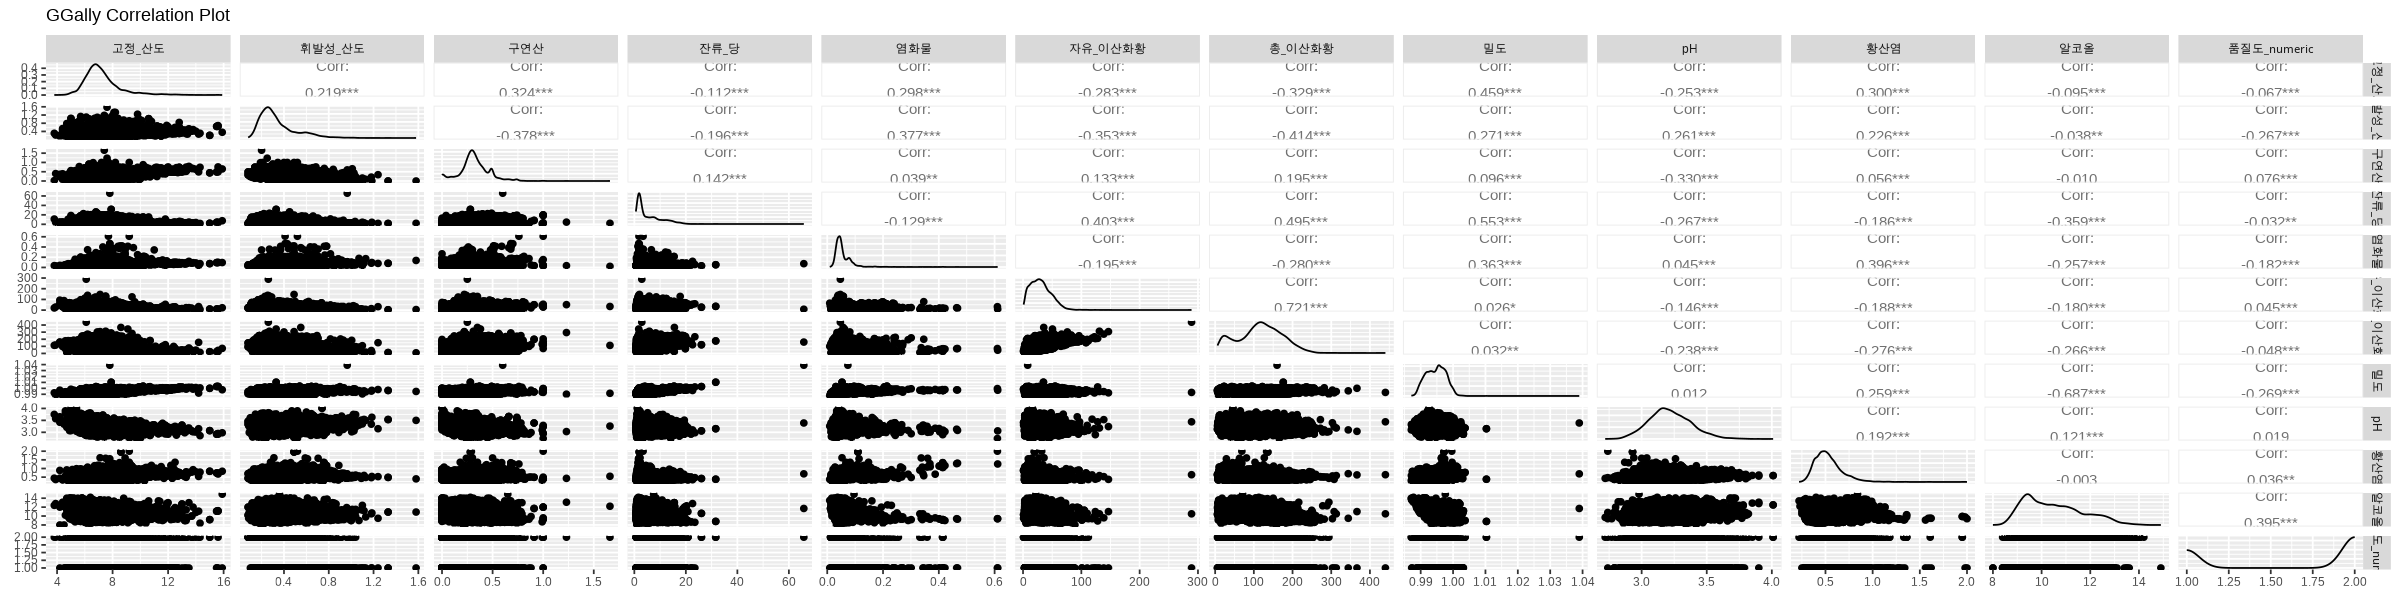

In [ ]:
# 필요한 라이브러리 로드
library(dplyr)
library(ggplot2)
library(GGally)
library(reshape2)

# Factor 변수를 numeric으로 변환
wine_quality$품질도_numeric <- as.numeric(as.factor(wine_quality$품질도))

# 연속형 변수 추출
numeric_vars <- names(wine_quality)[sapply(wine_quality, is.numeric)]

# 1. GGally::ggpairs()를 사용한 상관관계 시각화
ggpairs_plot <- ggpairs(
  wine_quality[, numeric_vars],
  title = "GGally Correlation Plot"
)
print(ggpairs_plot)




Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘quadprog’, ‘zoo’


Loading required package: xts

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:data.table’:

    yearmon, yearqtr


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                                             #
# Use stats::lag() to make sure you're not using dplyr::lag(), or you can add #
# conflictRules('dplyr', exclude = '

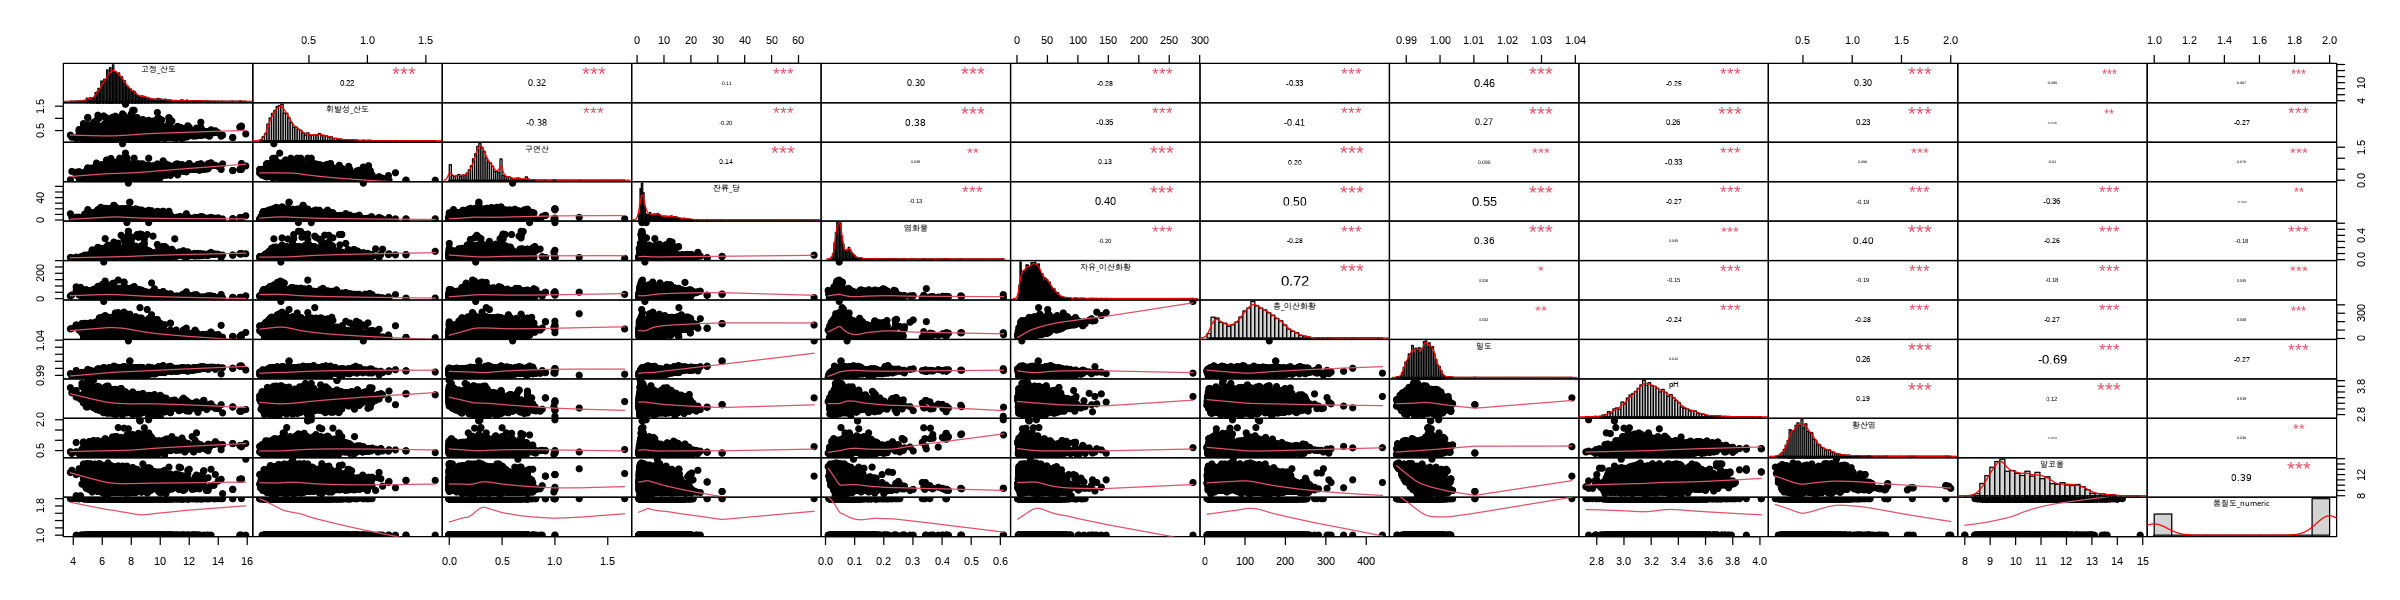

In [ ]:
# PerformanceAnalytics 패키지 설치 및 로드
install.packages("PerformanceAnalytics")
library(PerformanceAnalytics)

# 숫자형 변수 선택
numeric_vars <- names(wine_quality)[sapply(wine_quality, is.numeric)]

# 기존 par 설정 저장
old_par <- par(no.readonly = TRUE)  # 현재 그래픽 설정 저장

# 경고 메시지 방지 및 플롯 출력
suppressWarnings({
  PerformanceAnalytics::chart.Correlation(
    wine_quality[, numeric_vars],
    histogram = TRUE,  # 히스토그램 추가
    pch = 19           # 점 모양 설정
  )
})

# par 설정 복원
par(old_par)  # 그래픽 설정 복원


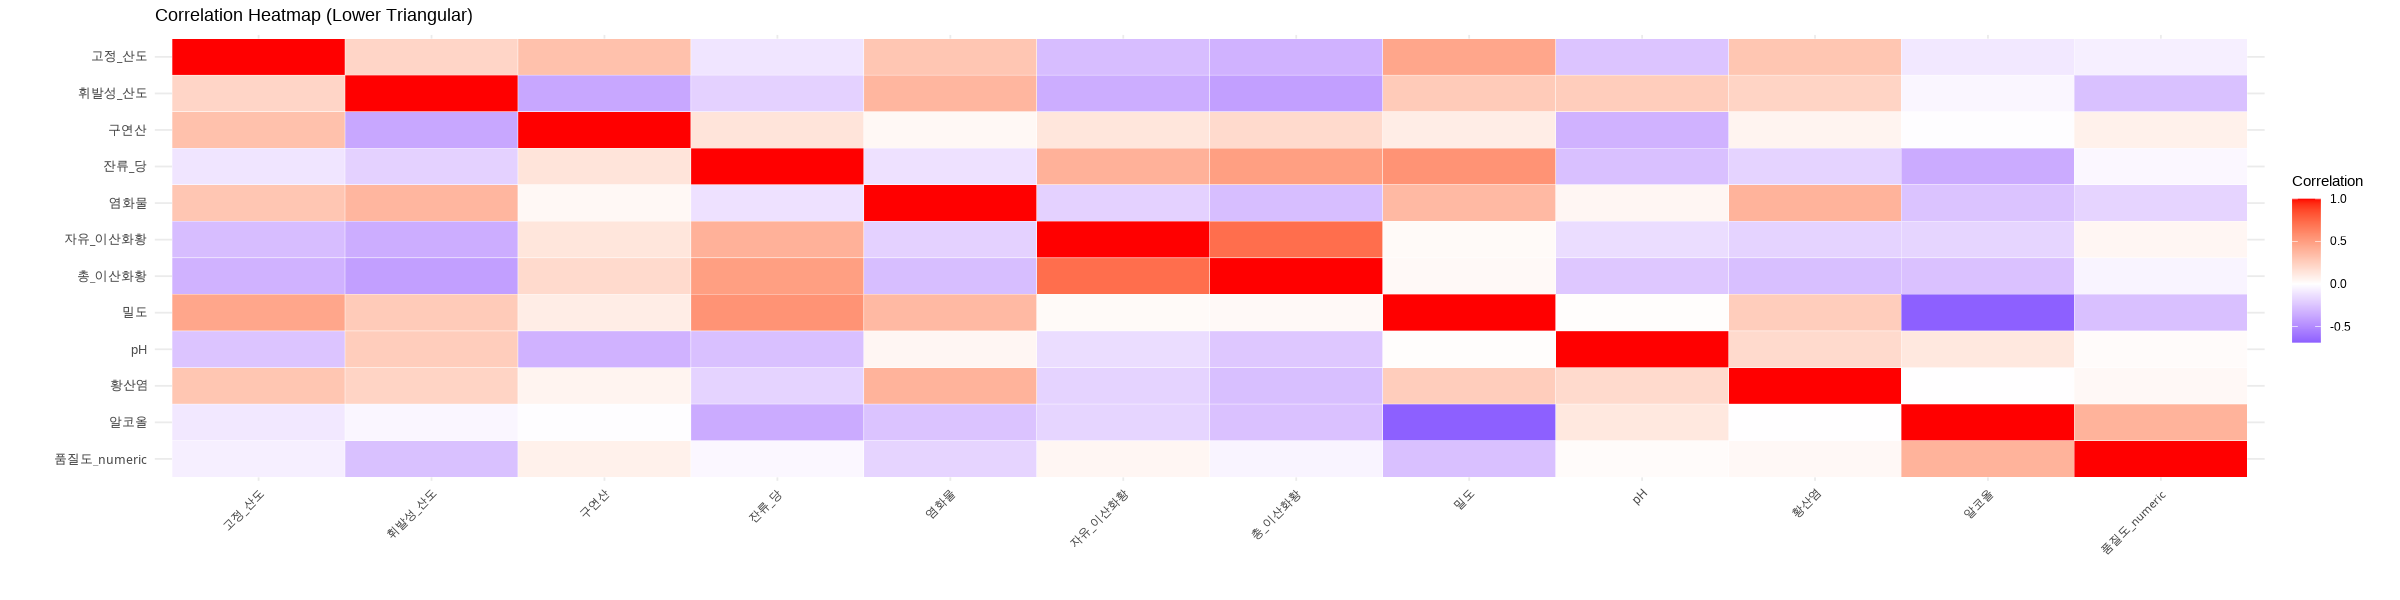

In [ ]:
# 필요한 라이브러리 로드
library(reshape2)
library(ggplot2)

# 상관계수 계산
correlation_matrix <- cor(wine_quality[numeric_vars], use = "complete.obs")

# melt 함수로 long 포맷 변환
cor_melted <- melt(correlation_matrix, na.rm = TRUE)

# y축 변수 순서를 x축과 반대로 배치
cor_melted$Var2 <- factor(cor_melted$Var2, levels = rev(levels(cor_melted$Var1)))

# 히트맵 생성

heatmap_plot <- ggplot(cor_melted, aes(Var1, Var2, fill = value)) +
  geom_tile(color = "white") +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", midpoint = 0) +
  labs(title = "Correlation Heatmap (Lower Triangular)", x = "", y = "", fill = "Correlation") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.text.y = element_text(size = 10)
  )

# 히트맵 출력
print(heatmap_plot)


In [ ]:
# ANOVA 분석
anova_results <- list()
for (var in setdiff(numeric_vars, "품질도_numeric")) {
  aov_result <- aov(as.formula(paste(var, "~ 품질도")), data = wine_quality)
  anova_results[[var]] <- summary(aov_result)
}

# ANOVA 결과에서 유의한 변수 선택
anova_p_values <- sapply(anova_results, function(x) x[[1]]$`Pr(>F)`[1])
anova_significant_vars <- names(sort(anova_p_values))[1:5]
print(anova_significant_vars)


[1] "알코올"      "밀도"        "휘발성_산도" "염화물"      "구연산"     


In [ ]:
# CART 모델로 변수 중요도 확인
library(rpart)

# 품질도를 반응변수로 하는 분류 모델 생성
cart_model <- rpart(품질도 ~ ., data = wine_quality %>% select(-품질도_numeric))

# 변수 중요도 추출
importance <- as.data.frame(cart_model$variable.importance)
importance <- importance[order(importance$`cart_model$variable.importance`, decreasing = TRUE), , drop = FALSE]
colnames(importance) <- "Importance"
print(importance)

# 상위 5개 변수 선택
top_5_vars <- rownames(importance)[1:5]
print(top_5_vars)


              Importance
알코올        406.247308
밀도          194.516790
휘발성_산도   144.511099
염화물        114.529048
잔류_당       108.512910
총_이산화황   100.341458
자유_이산화황  60.918516
pH              3.853629
[1] "알코올"      "밀도"        "휘발성_산도" "염화물"      "잔류_당"    


In [ ]:
# 상관계수 기반 상위 변수와 CART 변수 중요도 기반 상위 변수를 통합
top_vars_combined <- unique(c(anova_significant_vars, top_5_vars))
print(top_vars_combined)


[1] "알코올"      "밀도"        "휘발성_산도" "염화물"      "구연산"     
[6] "잔류_당"    


## 상관계수와 중요도 분석 후 상위 5개의 변수를 설명변수로 채택하였다.
##채택 과정에서 염화물은 제외하기로 결정하였다.
##최종적으로 설명변수로 채택한 변수는 알코올, 밀도, 휘발성 산도, 구연산, 잔류당이다.

In [ ]:
#중요도 분석을 위해 numeric으로 변환한 품질도를 다시 factor로 변환
# 기존 품질도 numeric 변수를 다시 factor로 변환
wine_quality$품질도 <- factor(wine_quality$품질도_numeric,
                             labels = c("기본품질", "우수품질"))

# 변환 후 확인
str(wine_quality$품질도)
table(wine_quality$품질도)


 Factor w/ 2 levels "기본품질","우수품질": 2 2 2 2 2 2 2 2 2 2 ...



기본품질 우수품질 
    2384     4113 

In [ ]:
# 필요한 변수만 남기기
wine_quality <- wine_quality %>%
  select(알코올, 밀도, 휘발성_산도, 구연산, 잔류_당, 품질도)

summary(wine_quality)

     알코올           밀도         휘발성_산도         구연산      
 Min.   : 8.00   Min.   :0.9871   Min.   :0.0800   Min.   :0.0000  
 1st Qu.: 9.50   1st Qu.:0.9923   1st Qu.:0.2300   1st Qu.:0.2500  
 Median :10.30   Median :0.9949   Median :0.2900   Median :0.3100  
 Mean   :10.49   Mean   :0.9947   Mean   :0.3397   Mean   :0.3186  
 3rd Qu.:11.30   3rd Qu.:0.9970   3rd Qu.:0.4000   3rd Qu.:0.3900  
 Max.   :14.90   Max.   :1.0390   Max.   :1.5800   Max.   :1.6600  
    잔류_당            품질도    
 Min.   : 0.600   기본품질:2384  
 1st Qu.: 1.800   우수품질:4113  
 Median : 3.000                  
 Mean   : 5.443                  
 3rd Qu.: 8.100                  
 Max.   :65.800                  

In [ ]:
summary(wine_quality)
str(wine_quality)

     알코올           밀도         휘발성_산도         구연산      
 Min.   : 8.00   Min.   :0.9871   Min.   :0.0800   Min.   :0.0000  
 1st Qu.: 9.50   1st Qu.:0.9923   1st Qu.:0.2300   1st Qu.:0.2500  
 Median :10.30   Median :0.9949   Median :0.2900   Median :0.3100  
 Mean   :10.49   Mean   :0.9947   Mean   :0.3397   Mean   :0.3186  
 3rd Qu.:11.30   3rd Qu.:0.9970   3rd Qu.:0.4000   3rd Qu.:0.3900  
 Max.   :14.90   Max.   :1.0390   Max.   :1.5800   Max.   :1.6600  
    잔류_당            품질도    
 Min.   : 0.600   기본품질:2384  
 1st Qu.: 1.800   우수품질:4113  
 Median : 3.000                  
 Mean   : 5.443                  
 3rd Qu.: 8.100                  
 Max.   :65.800                  

tibble [6,497 × 6] (S3: tbl_df/tbl/data.frame)
 $ 알코올     : num [1:6497] 8.8 9.5 10.1 9.9 9.9 10.1 9.6 8.8 9.5 11 ...
 $ 밀도       : num [1:6497] 1.001 0.994 0.995 0.996 0.996 ...
 $ 휘발성_산도: num [1:6497] 0.27 0.3 0.28 0.23 0.23 0.28 0.32 0.27 0.3 0.22 ...
 $ 구연산     : num [1:6497] 0.36 0.34 0.4 0.32 0.32 0.4 0.16 0.36 0.34 0.43 ...
 $ 잔류_당    : num [1:6497] 20.7 1.6 6.9 8.5 8.5 6.9 7 20.7 1.6 1.5 ...
 $ 품질도     : Factor w/ 2 levels "기본품질","우수품질": 2 2 2 2 2 2 2 2 2 2 ...
 - attr(*, ".internal.selfref")=<externalptr> 


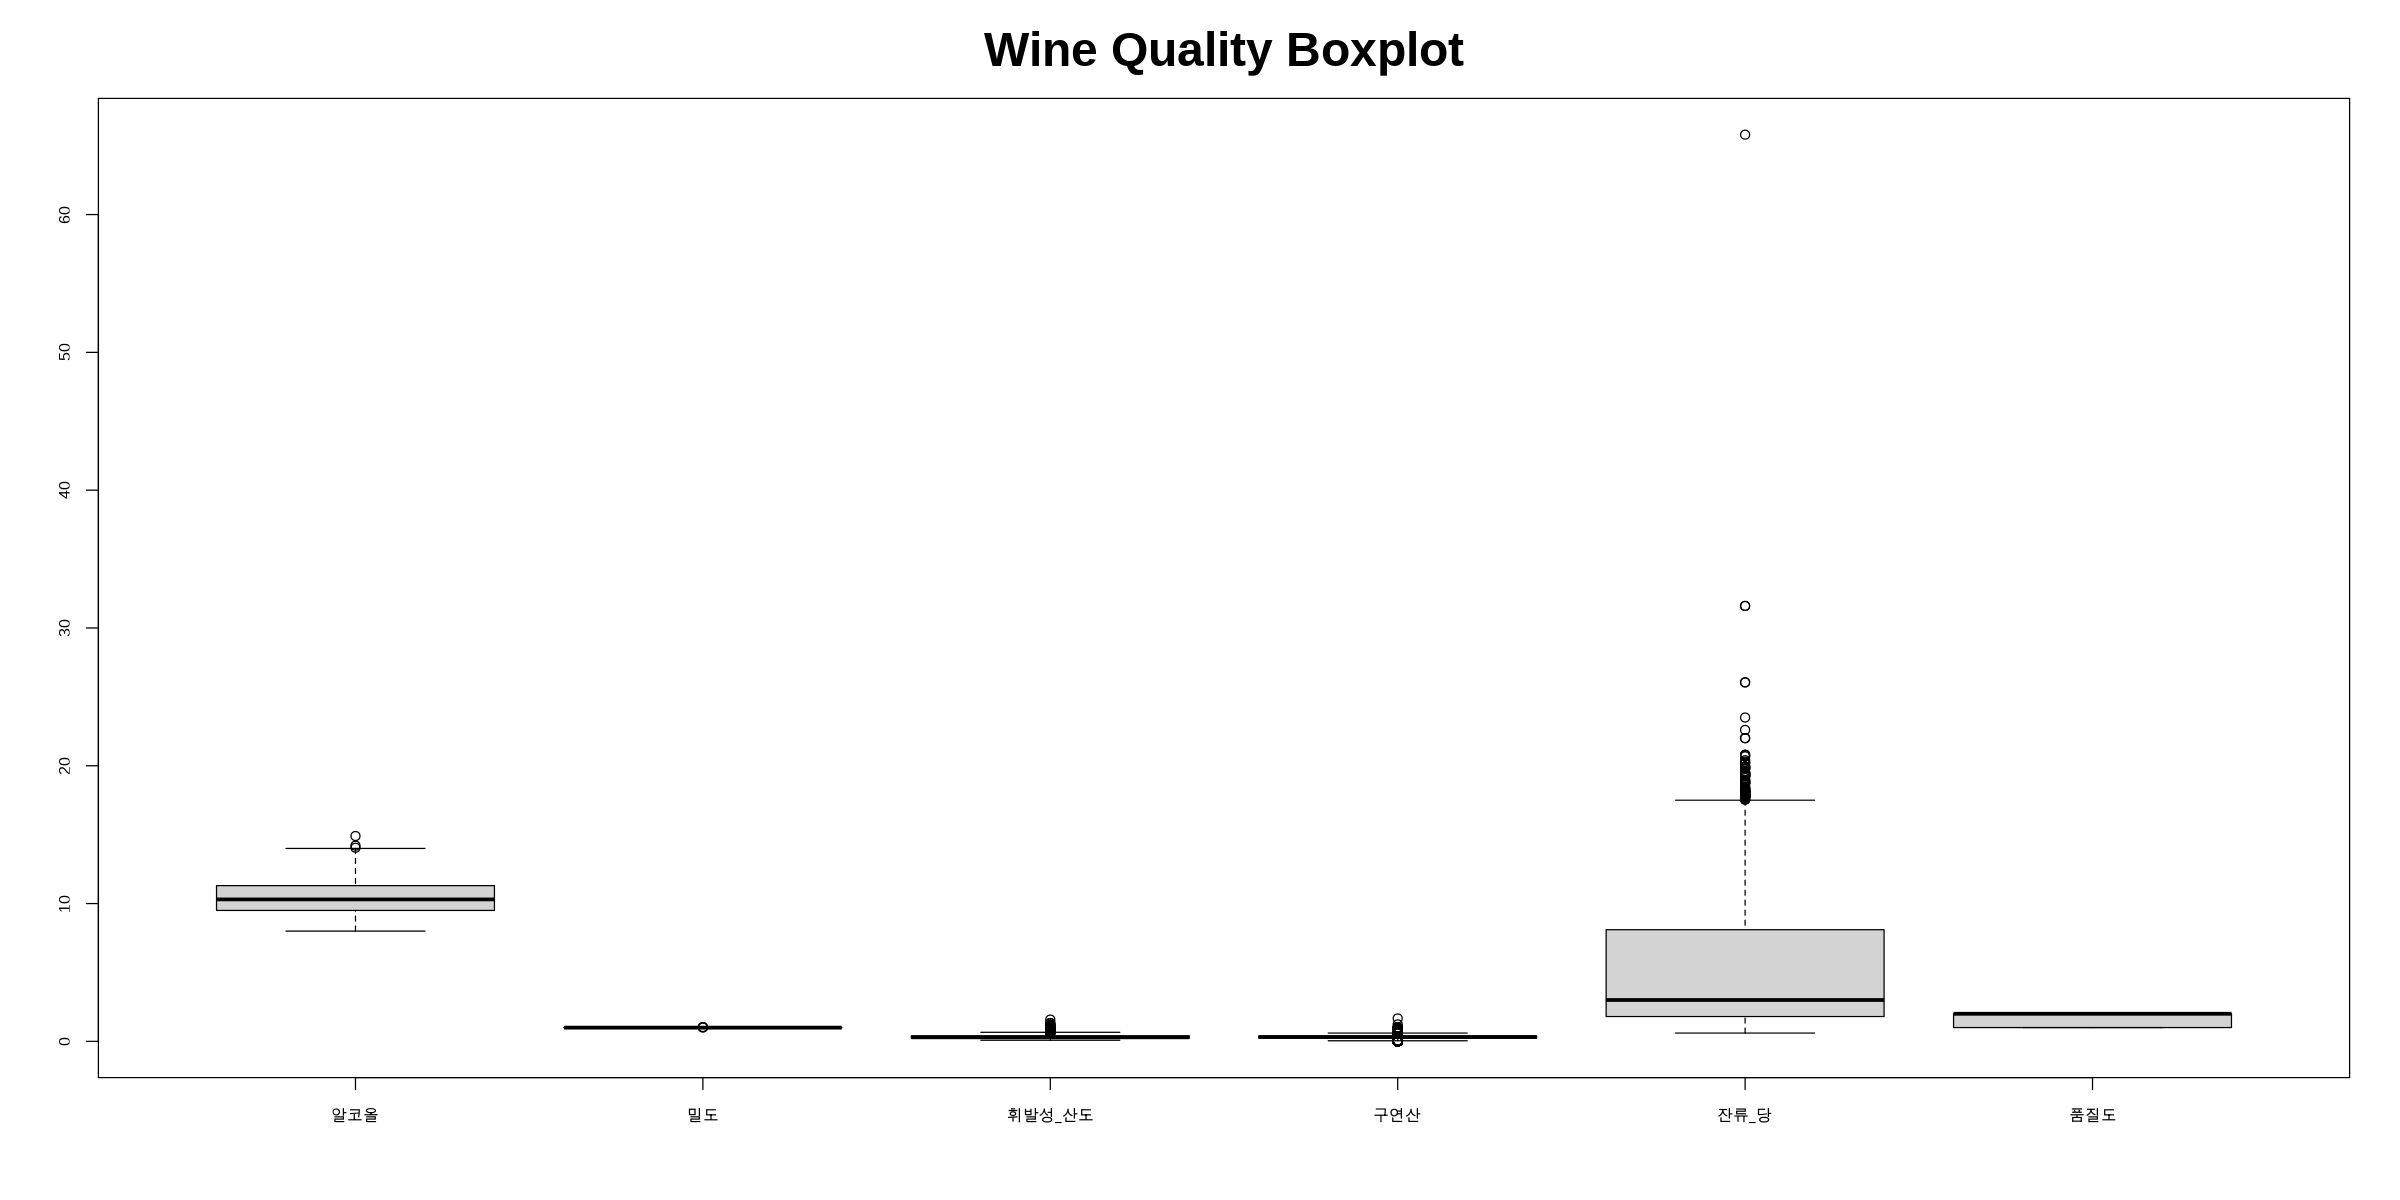

In [ ]:
#전처리 전 이상값 확인
options(repr.plot.width=20, repr.plot.height=10)  # (가로, 세로) 단위는 inches
boxplot(wine_quality,
        main="Wine Quality Boxplot",
        cex.main=3,     # 제목 폰트 크기
        cex.lab=1.5,    # 축 레이블 폰트 크기
        cex.axis=1)   # 축 눈금 폰트 크기

In [ ]:
# #와인 종류 -> 범주형 변수 변환
# #범주형 데이터이므로 모델 학습에 적합한 형태로 변환 (사실 위에서 함)
# wine_quality$와인_종류 <- as.factor(wine_quality$와인_종류)


# #고정 산도 -> 스케일링(표준화)
# # 분포가 비교적 정규분포에 가까우며, 모델 학습 시 단위 차이를 줄이기 위해 스케일 조정.
# wine_quality$고정_산도 <- scale(wine_quality$고정_산도)


# #휘발성 산도 -> 스케일링(표준화)
# #비대칭 분포이며, 다른 산도 변수와 비교 가능하도록 스케일링 필요.
# wine_quality$휘발성_산도 <- scale(wine_quality$휘발성_산도)

# #구연산 -> 스케일링 (표준화).
# #모델에 중요한 기여를 할 가능성이 크며, 다른 변수와의 균형을 맞추기 위해 스케일링.
# wine_quality$구연산 <- scale(wine_quality$구연산)

# #잔류당 -> 로그 변환
# #분포가 심하게 왜곡되어 있으므로, 로그 변환으로 정규성을 개선.
# wine_quality$잔류_당 <- log(wine_quality$잔류_당)

# #염화물 -> 역수 변환
# #대부분의 값이 작고, 분포를 조정하여 극단적인 값을 줄이기 위해 역수 변환 수행.
# wine_quality$염화물 <- 1 / wine_quality$염화물

# #자유 이산화황 -> 로그 변환
# #비대칭 분포이며, 정규성 확보를 위해 로그 변환.
# wine_quality$자유_이산화황 <- log(wine_quality$자유_이산화황)

# #총 이산화황 -> 로그 변환.
# #자유 이산화황과 유사한 분포로, 정규성을 개선하기 위해 로그 변환.
# # wine_quality$총_이산화황 <- log(wine_quality$총_이산화황)


# #밀도 -> 스케일링 (표준화)
# #범위는 좁지만, 다른 변수와의 스케일을 맞추기 위해 표준화 필요.
# wine_quality$밀도 <- scale(wine_quality$밀도)

# #pH -> 스케일링 (표준화)
# #값의 범위가 좁아 보이지만, 다른 변수와의 균형을 위해 표준화가 적합.
# wine_quality$pH <- scale(wine_quality$pH)

# #황산염 -> 로그 변환
# #작은 값에 집중되어 있으므로, 로그 변환으로 정규성을 개선.
# wine_quality$황산염 <- log(wine_quality$황산염)

# #알코올 -> 스케일링 (표준화).
# #모델의 주요 변수로 작용할 가능성이 크며, 다른 변수와의 비교를 위해 표준화.
# wine_quality$알코올 <- scale(wine_quality$알코올)


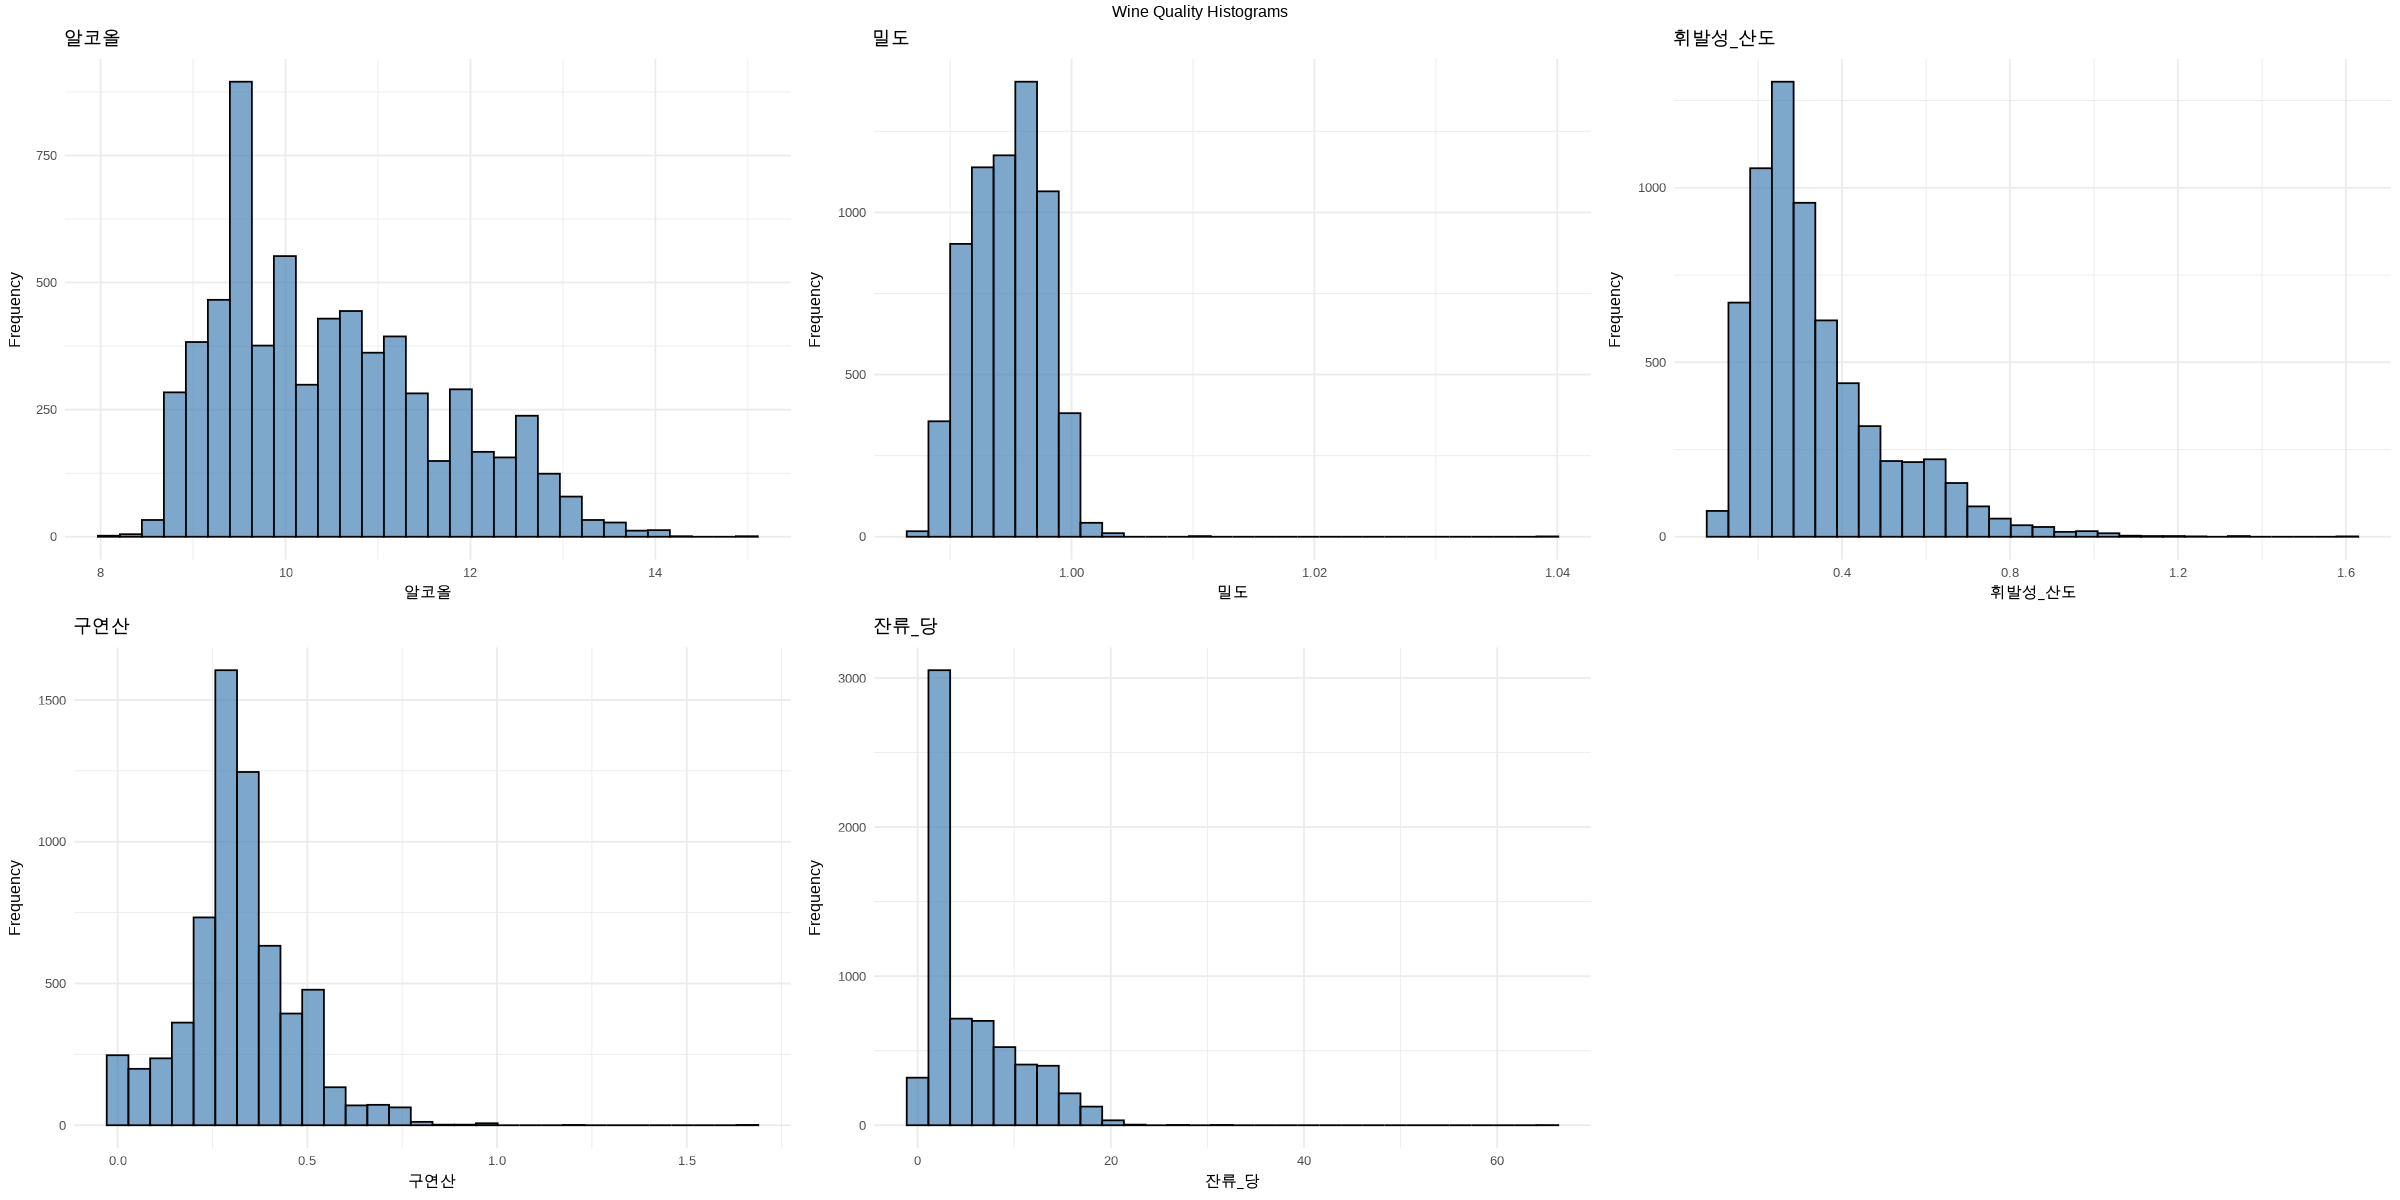

In [ ]:
#데이터 전처리 전 각 변수의 시각화 (히스토그램)


# 숫자형 변수 선택
numeric_vars <- names(wine_quality)[sapply(wine_quality, is.numeric)]

# 히스토그램 저장할 리스트 생성
plots <- list()

for (var in numeric_vars) {
  p <- ggplot(wine_quality, aes(x = .data[[var]])) +  # aes()와 tidy eval 사용
    geom_histogram(bins = 30, fill = "steelblue", color = "black", alpha = 0.7) +
    labs(title = var, x = var, y = "Frequency") +
    theme_minimal() +
    theme(
      plot.title = element_text(size = 14),  # 제목 크기 조정
      axis.title = element_text(size = 12), # 축 제목 크기 조정
      axis.text = element_text(size = 10)   # 축 값 크기 조정
    )
  plots[[var]] <- p
}

# 그래프 크기 조정 및 레이아웃 변경
do.call(grid.arrange, c(plots, ncol = 3, top = "Wine Quality Histograms"))


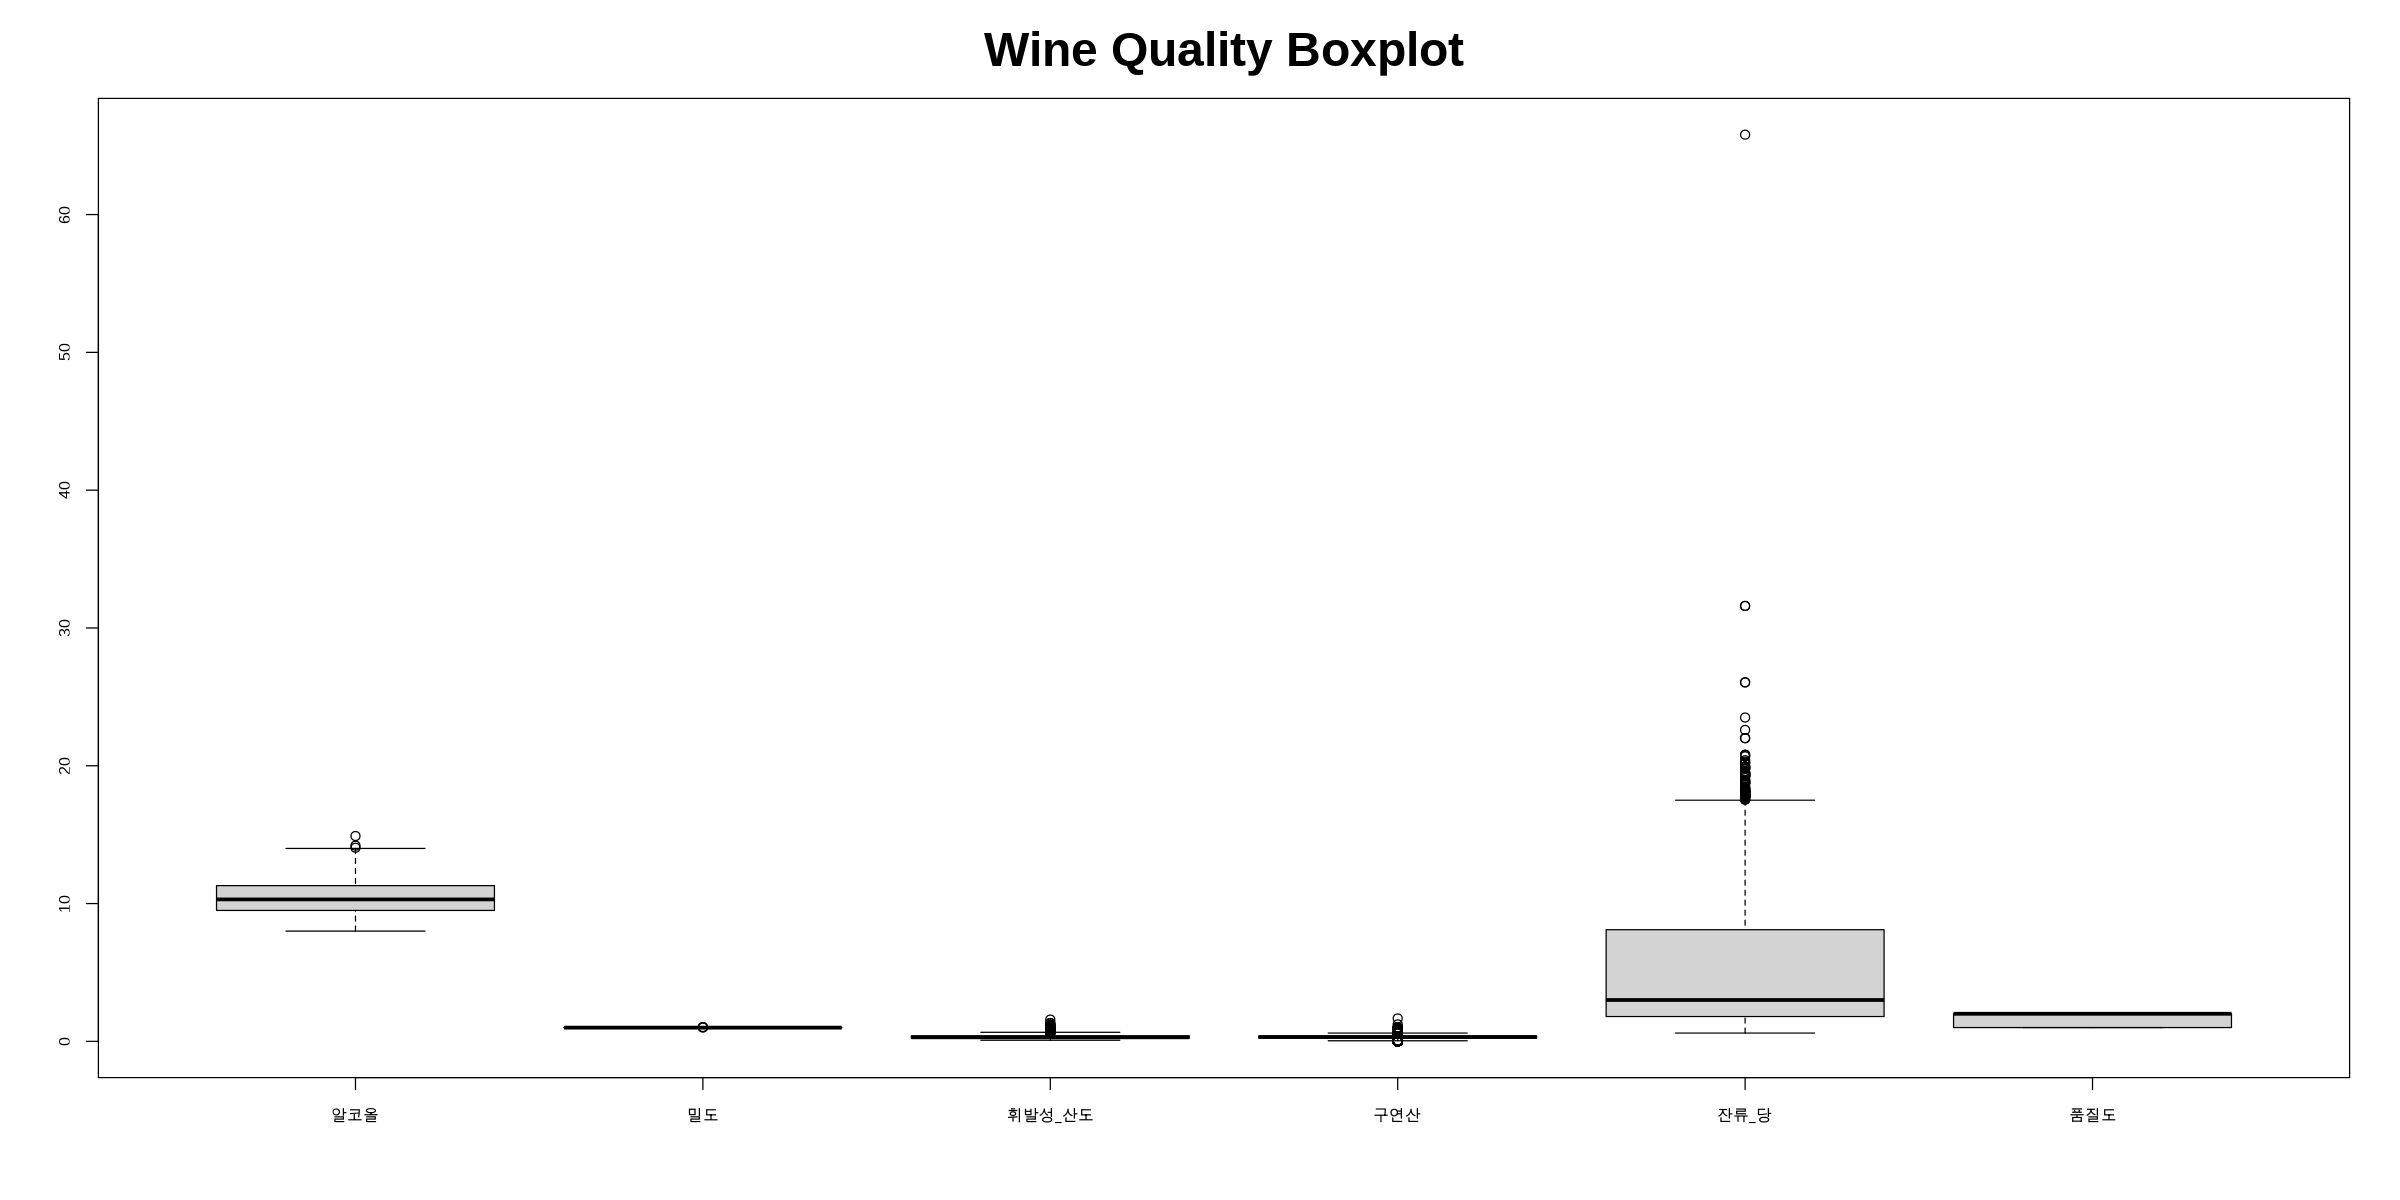

In [ ]:
options(repr.plot.width=20, repr.plot.height=10)  # (가로, 세로) 단위는 inches
boxplot(wine_quality,
        main="Wine Quality Boxplot",
        cex.main=3,     # 제목 폰트 크기
        cex.lab=1.5,    # 축 레이블 폰트 크기
        cex.axis=1)   # 축 눈금 폰트 크기

In [ ]:
#1. 알코올: 표준화 후 양수로 변환
wine_quality <- wine_quality %>%
  mutate(알코올 = scale(알코올)) %>%
  mutate(알코올 = 알코올 - min(알코올) + 1)

# 2. 밀도: 최소-최대 스케일링 (양수 범위)
wine_quality <- wine_quality %>%
  mutate(밀도 = (밀도 - min(밀도)) / (max(밀도) - min(밀도)))

# 3. 휘발성 산도: 로그 변환 후 양수로 보정
wine_quality <- wine_quality %>%
  mutate(휘발성_산도 = log(휘발성_산도 + 1)) %>%
  mutate(휘발성_산도 = 휘발성_산도 - min(휘발성_산도) + 1)

# 4. 구연산: 이상값 제거 후 표준화 및 양수 변환
remove_outliers <- function(data, column) {
  Q1 <- quantile(data[[column]], 0.25)
  Q3 <- quantile(data[[column]], 0.75)
  IQR <- Q3 - Q1
  lower_bound <- Q1 - 1.5 * IQR
  upper_bound <- Q3 + 1.5 * IQR
  data <- data %>% filter(data[[column]] >= lower_bound & data[[column]] <= upper_bound)
  return(data)
}

wine_quality <- remove_outliers(wine_quality, "구연산")
wine_quality <- wine_quality %>%
  mutate(구연산 = scale(구연산)) %>%
  mutate(구연산 = 구연산 - min(구연산) + 1)

# 5. 잔류 당: 이상값 제거 후 로그 변환 및 최소-최대 스케일링 (양수 범위)
wine_quality <- remove_outliers(wine_quality, "잔류_당")
wine_quality <- wine_quality %>%
  mutate(잔류_당 = log(잔류_당 + 1)) %>%
  mutate(잔류_당 = (잔류_당 - min(잔류_당)) / (max(잔류_당) - min(잔류_당))) %>%
  mutate(잔류_당 = 잔류_당 + 1)  # 양수 범위로 조정

# 결과 확인
summary(wine_quality)


     알코올.V1           밀도          휘발성_산도        구연산.V1     
 Min.   :1.000000   Min.   :0.00000   Min.   :1.000   Min.   :1.000000  
 1st Qu.:2.257638   1st Qu.:0.09635   1st Qu.:1.122   1st Qu.:2.990873  
 Median :3.012221   Median :0.14440   Median :1.170   Median :3.443344  
 Mean   :3.116621   Mean   :0.14208   Mean   :1.199   Mean   :3.514704  
 3rd Qu.:3.766804   3rd Qu.:0.18590   3rd Qu.:1.245   3rd Qu.:4.076804  
 Max.   :6.198238   Max.   :0.31965   Max.   :1.730   Max.   :6.067677  
    잔류_당           품질도    
 Min.   :1.000   기본품질:2075  
 1st Qu.:1.227   우수품질:3813  
 Median :1.382                  
 Mean   :1.463                  
 3rd Qu.:1.702                  
 Max.   :2.000                  

##4. 데이터 시각화

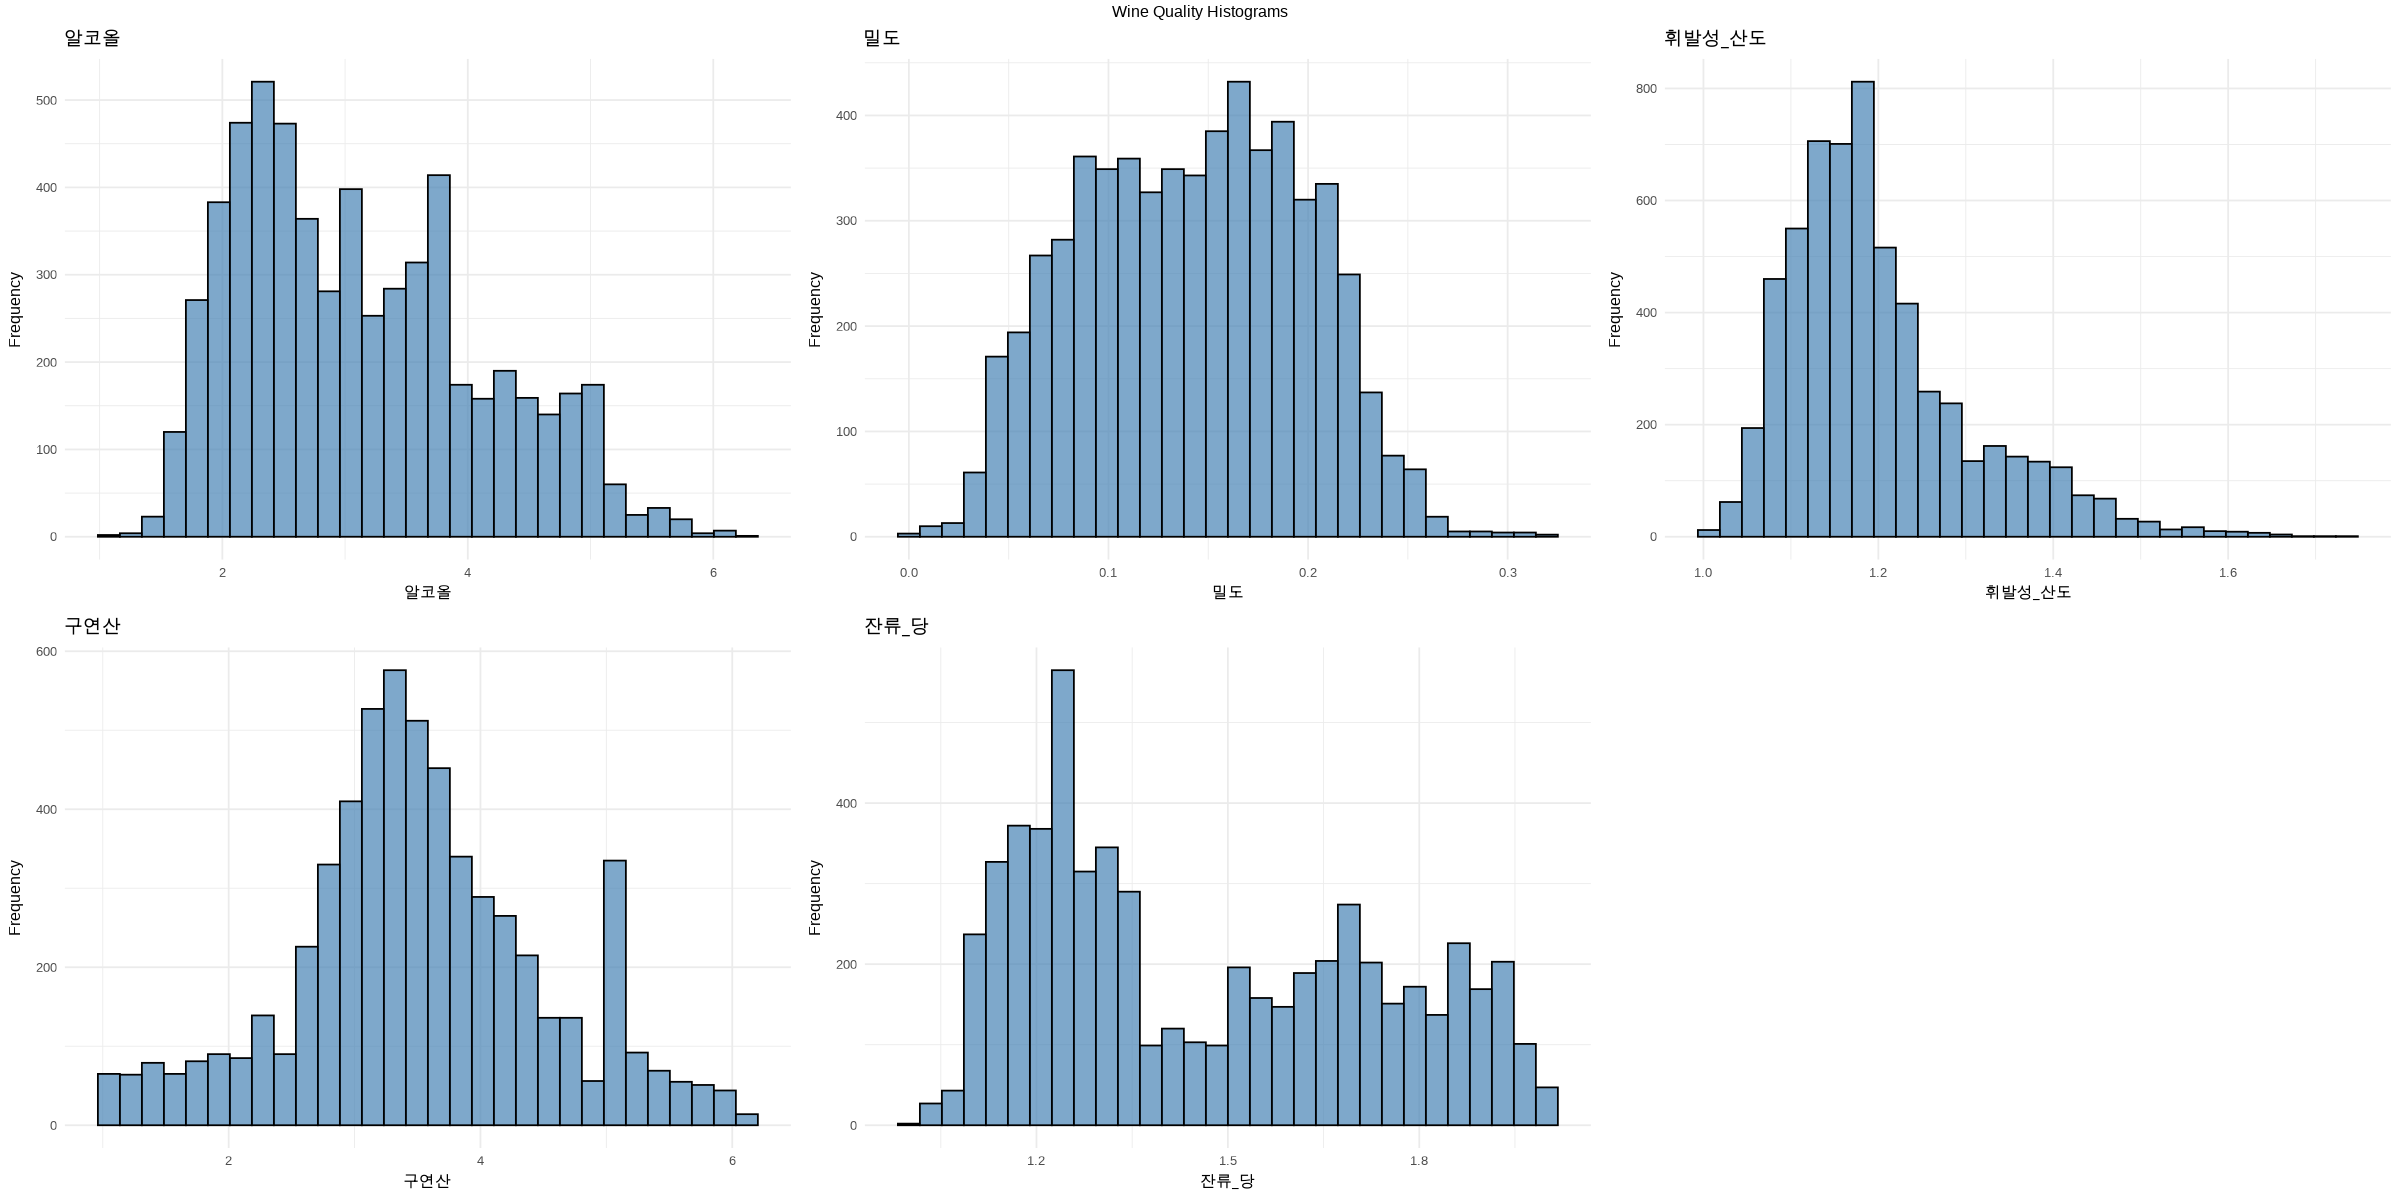

In [ ]:
#데이터 전처리 후 각 변수의 시각화 (히스토그램)


# 숫자형 변수 선택
numeric_vars <- names(wine_quality)[sapply(wine_quality, is.numeric)]

# 히스토그램 저장할 리스트 생성
plots <- list()

for (var in numeric_vars) {
  p <- ggplot(wine_quality, aes(x = .data[[var]])) +  # aes()와 tidy eval 사용
    geom_histogram(bins = 30, fill = "steelblue", color = "black", alpha = 0.7) +
    labs(title = var, x = var, y = "Frequency") +
    theme_minimal() +
    theme(
      plot.title = element_text(size = 14),  # 제목 크기 조정
      axis.title = element_text(size = 12), # 축 제목 크기 조정
      axis.text = element_text(size = 10)   # 축 값 크기 조정
    )
  plots[[var]] <- p
}

# 그래프 크기 조정 및 레이아웃 변경
do.call(grid.arrange, c(plots, ncol = 3, top = "Wine Quality Histograms"))


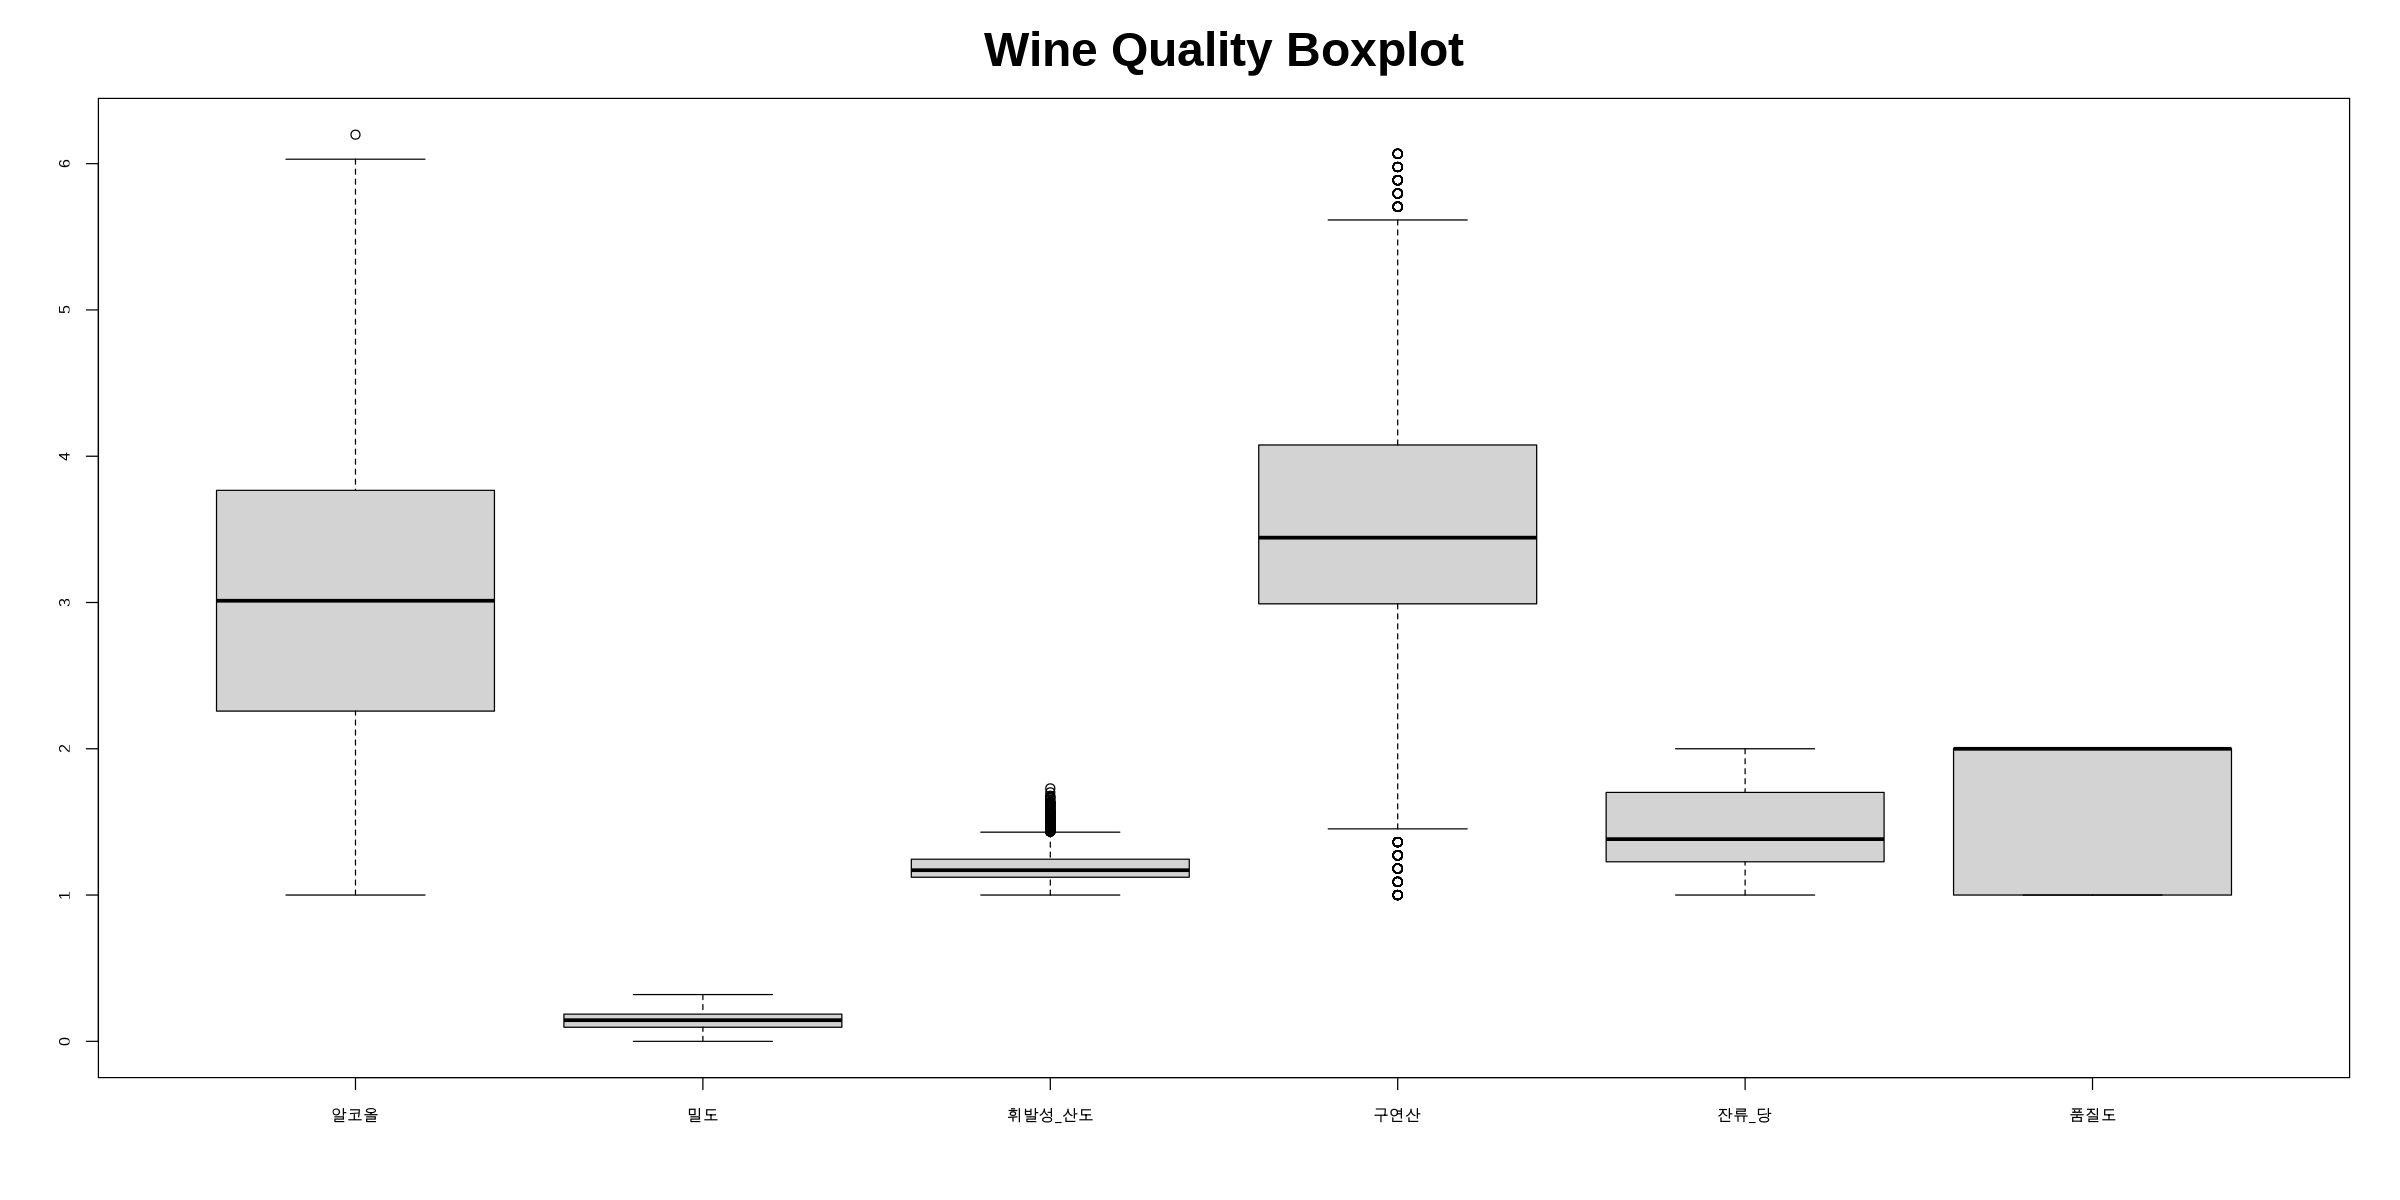

In [ ]:
options(repr.plot.width=20, repr.plot.height=10)  # (가로, 세로) 단위는 inches
boxplot(wine_quality,
        main="Wine Quality Boxplot",
        cex.main=3,     # 제목 폰트 크기
        cex.lab=1.5,    # 축 레이블 폰트 크기
        cex.axis=1)   # 축 눈금 폰트 크기

In [ ]:
# 결측값 확인
wine_na <- sum(is.na(wine_quality))
wine_na %>% show()


[1] 0


#모델링

In [ ]:
install.packages("MLmetrics")
library(MLmetrics)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gtools’, ‘caTools’, ‘gplots’, ‘ROCR’



Attaching package: ‘MLmetrics’


The following object is masked from ‘package:psych’:

    AUC


The following objects are masked from ‘package:caret’:

    MAE, RMSE


The following object is masked from ‘package:base’:

    Recall




In [ ]:
# 데이터 분리 (75% 훈련, 25% 테스트)
set.seed(123)  # 재현성을 위해 설정
train_index <- createDataPartition(wine_quality$품질도, p = 0.75, list = FALSE)
train_data <- wine_quality[train_index, ]
test_data <- wine_quality[-train_index, ]

# 설명변수와 반응변수 분리
x_train <- train_data[, c("알코올", "밀도", "휘발성_산도", "구연산", "잔류_당")]
y_train <- train_data$품질도
x_test <- test_data[, c("알코올", "밀도", "휘발성_산도", "구연산", "잔류_당")]
y_test <- test_data$품질도

In [ ]:
# 로지스틱 회귀

# 튜닝 및 모델 학습
log_tune <- train(
  품질도 ~ 알코올 + 밀도 + 휘발성_산도 + 구연산 + 잔류_당,
  data = train_data,
  method = "glm",
  family = "binomial",
  trControl = trainControl(method = "cv", number = 5)  # 5-fold 교차검증
)

# 최적 모델 출력
print(log_tune)

# 예측
log_pred <- predict(log_tune, newdata = x_test)

# 정확도 및 F1-score 계산
log_accuracy <- mean(log_pred == y_test)
log_f1 <- F1_Score(y_pred = log_pred, y_true = y_test, positive = levels(y_test)[2])

# Confusion Matrix 생성
log_conf_matrix <- confusionMatrix(as.factor(log_pred), as.factor(y_test))

# 출력
cat("로지스틱 회귀 튜닝 후 Accuracy:", log_accuracy, "\n")
cat("로지스틱 회귀 튜닝 후 F1-Score:", log_f1, "\n")
print(log_conf_matrix)


Generalized Linear Model 

4417 samples
   5 predictor
   2 classes: '기본품질', '우수품질' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 3534, 3533, 3534, 3534, 3533 
Resampling results:

  Accuracy   Kappa    
  0.7457552  0.4124534

로지스틱 회귀 튜닝 후 Accuracy: 0.757308 
로지스틱 회귀 튜닝 후 F1-Score: 0.8257687 
Confusion Matrix and Statistics

          Reference
Prediction 기본품질 우수품질
  기본품질      268      107
  우수품질      250      846
                                         
               Accuracy : 0.7573         
                 95% CI : (0.7346, 0.779)
    No Information Rate : 0.6479         
    P-Value [Acc > NIR] : < 2.2e-16      
                                         
                  Kappa : 0.4323         
                                         
 Mcnemar's Test P-Value : 5.672e-14      
                                         
            Sensitivity : 0.5174         
            Specificity : 0.8877         
         Pos Pred Value : 0.7147        

CART 

4417 samples
   5 predictor
   2 classes: '기본품질', '우수품질' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 3534, 3534, 3533, 3534, 3533 
Resampling results across tuning parameters:

  cp    Accuracy   Kappa    
  0.01  0.7373746  0.4007211
  0.02  0.7362421  0.4078410
  0.03  0.7362421  0.4078410
  0.04  0.7362421  0.4078410
  0.05  0.7362421  0.4078410
  0.06  0.7362421  0.4078410
  0.07  0.7362421  0.4078410
  0.08  0.7362421  0.4078410
  0.09  0.7362421  0.4078410
  0.10  0.7362421  0.4078410

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was cp = 0.01.
Decision Tree 튜닝 후 Accuracy: 0.7539089 
Decision Tree 튜닝 후 F1-Score: 0.8200795 
Confusion Matrix and Statistics

          Reference
Prediction 기본품질 우수품질
  기본품질      284      128
  우수품질      234      825
                                          
               Accuracy : 0.7539          
                 95% CI : (0.7311, 0.7757)
   

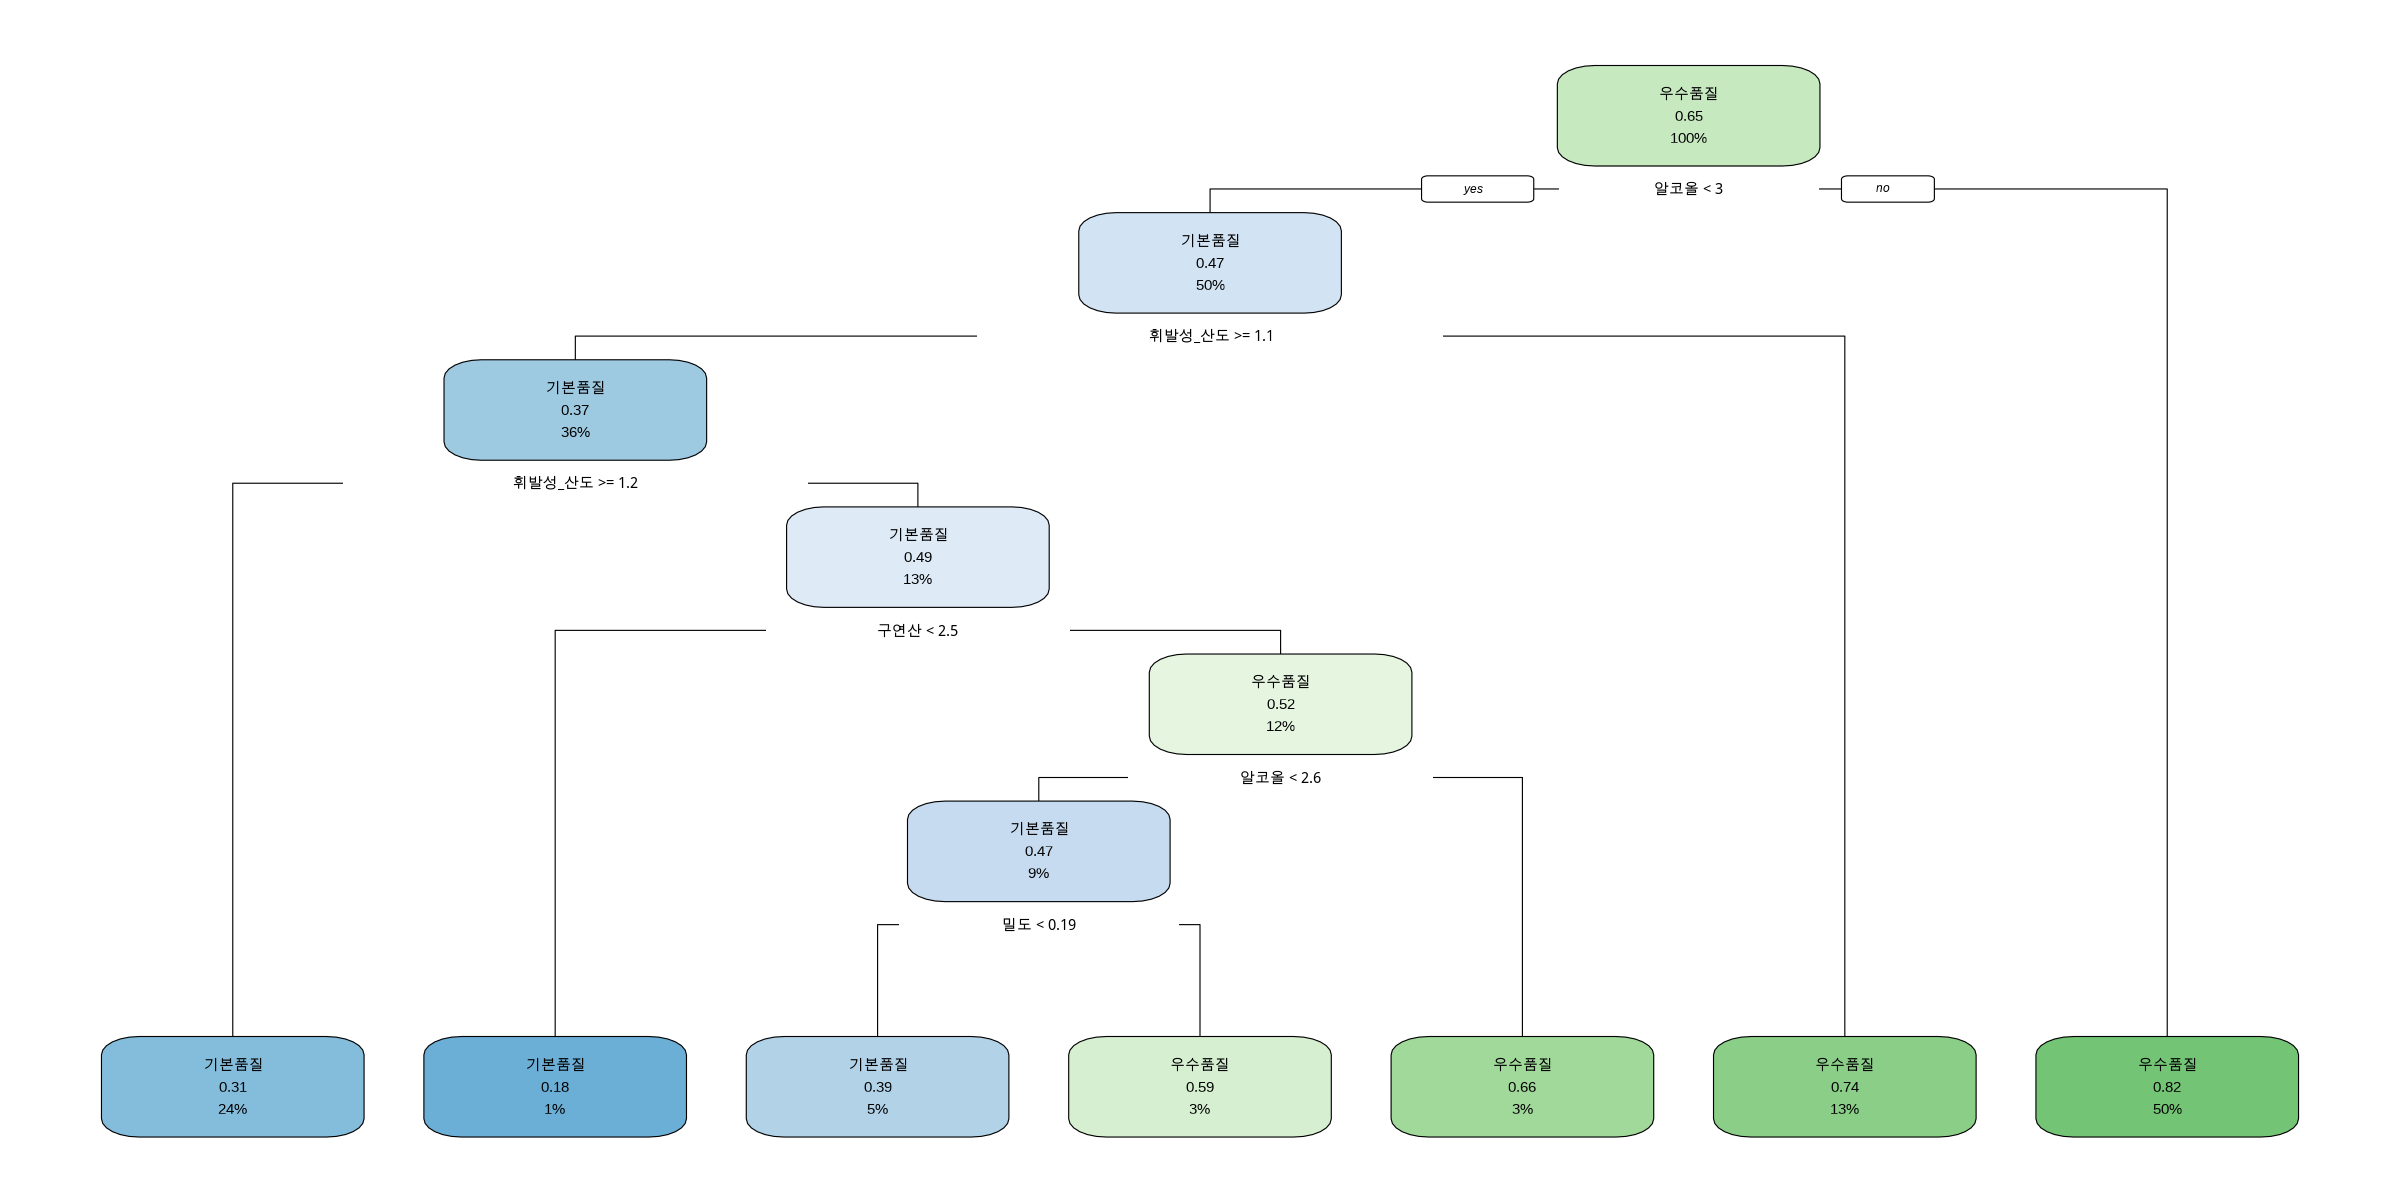

In [ ]:
# 필요한 라이브러리 로드
library(rpart)

# 튜닝 및 모델 학습
tree_tune <- train(
  품질도 ~ 알코올 + 밀도 + 휘발성_산도 + 구연산 + 잔류_당,
  data = train_data,
  method = "rpart",
  trControl = trainControl(method = "cv", number = 5),  # 5-fold 교차검증
  tuneGrid = expand.grid(cp = seq(0.01, 0.1, by = 0.01))  # cp 파라미터 튜닝
)

# 최적 모델 확인
print(tree_tune)

# 예측
tree_pred <- predict(tree_tune, newdata = x_test)

# 정확도 및 F1-score 계산
tree_accuracy <- mean(tree_pred == y_test)
tree_f1 <- F1_Score(y_pred = tree_pred, y_true = y_test, positive = levels(y_test)[2])

# Confusion Matrix 계산
confusion_matrix <- confusionMatrix(factor(tree_pred, levels = levels(y_test)), y_test)

# 출력
cat("Decision Tree 튜닝 후 Accuracy:", tree_accuracy, "\n")
cat("Decision Tree 튜닝 후 F1-Score:", tree_f1, "\n")
print(confusion_matrix)

# 최적 모델 시각화
rpart.plot(tree_tune$finalModel)


In [ ]:
install.packages("ipred")
library(ipred)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# 필요한 라이브러리 로드
library(ipred)
library(caret)
library(MLmetrics)

# Bagging 모델 학습 (튜닝 포함)
set.seed(123)  # 재현 가능성 설정
bagging_tune <- train(
  품질도 ~ 알코올 + 밀도 + 휘발성_산도 + 구연산 + 잔류_당,
  data = train_data,
  method = "treebag",  # Bagging 기반 트리 모델
  trControl = trainControl(method = "cv", number = 5)  # 5-fold 교차검증
)

# 최적 모델 확인
print(bagging_tune)

# 예측 및 평가
bagging_preds <- predict(bagging_tune, newdata = test_data)
bagging_accuracy <- mean(bagging_preds == test_data$품질도)
bagging_f1 <- F1_Score(y_true = test_data$품질도, y_pred = bagging_preds, positive = levels(test_data$품질도)[2])

# Confusion Matrix 생성
conf_matrix <- confusionMatrix(
  as.factor(bagging_preds),
  as.factor(test_data$품질도),
  positive = levels(test_data$품질도)[2]
)

# 결과 출력
cat("Bagging 튜닝 후 Accuracy:", bagging_accuracy, "\n")
cat("Bagging 튜닝 후 F1 Score:", bagging_f1, "\n")
print(conf_matrix)


Bagged CART 

4417 samples
   5 predictor
   2 classes: '기본품질', '우수품질' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 3534, 3534, 3533, 3534, 3533 
Resampling results:

  Accuracy   Kappa    
  0.7860525  0.5204527

Bagging 튜닝 후 Accuracy: 0.8021754 
Bagging 튜닝 후 F1 Score: 0.8505393 
Confusion Matrix and Statistics

          Reference
Prediction 기본품질 우수품질
  기본품질      352      125
  우수품질      166      828
                                          
               Accuracy : 0.8022          
                 95% CI : (0.7809, 0.8223)
    No Information Rate : 0.6479          
    P-Value [Acc > NIR] : < 2e-16         
                                          
                  Kappa : 0.5585          
                                          
 Mcnemar's Test P-Value : 0.01904         
                                          
            Sensitivity : 0.8688          
            Specificity : 0.6795          
         Pos Pred Value : 0.8330        

In [ ]:
# install.packages("adabag")
# library(adabag)


In [ ]:
# # AdaBoost

# # AdaBoost 모델 학습
# adaboost_model <- boosting(품질도 ~ 알코올 + 밀도 + 휘발성_산도 + 구연산 + 잔류_당,
#                            data = train_data, boos = TRUE, mfinal = 50)

# # 예측
# adaboost_pred <- predict(adaboost_model, newdata = test_data)$class

# # 정확도 및 F1-score 계산
# adaboost_accuracy <- mean(adaboost_pred == test_data$품질도)
# adaboost_f1 <- F1_Score(y_pred = adaboost_pred, y_true = test_data$품질도, positive = levels(test_data$품질도)[2])

# cat("AdaBoost Accuracy:", adaboost_accuracy, "\n")
# cat("AdaBoost F1-Score:", adaboost_f1, "\n")

# # Confusion Matrix 생성
# adaboost_conf_matrix <- confusionMatrix(as.factor(adaboost_pred), as.factor(test_data$품질도))

# # Confusion Matrix 출력
# cat("\nAdaBoost Confusion Matrix:\n")
# print(adaboost_conf_matrix)


In [ ]:
# install.packages("caretEnsemble")
# library(caretEnsemble)

In [ ]:
# # Stacking

# # 기본 모델 설정
# control <- trainControl(method = "cv", number = 5, savePredictions = "final", classProbs = TRUE)

# # 개별 모델 학습
# model_list <- caretList(
#   품질도 ~ 알코올 + 밀도 + 휘발성_산도 + 구연산 + 잔류_당,
#   data = train_data,
#   trControl = control,
#   methodList = c("rf", "glm", "svmRadial")
# )

# # Stacking 모델 학습
# stack_model <- caretStack(
#   model_list,
#   method = "glm",
#   metric = "Accuracy",
#   trControl = trainControl(method = "cv", number = 5, classProbs = TRUE)
# )

# # 예측
# stack_pred <- predict(stack_model, newdata = test_data)

# # 정확도 및 F1-score 계산
# stack_accuracy <- mean(stack_pred == test_data$품질도)
# stack_f1 <- F1_Score(y_pred = stack_pred, y_true = test_data$품질도, positive = levels(test_data$품질도)[2])

# cat("Stacking Accuracy:", stack_accuracy, "\n")
# cat("Stacking F1-Score:", stack_f1, "\n")

# # Confusion Matrix 생성
# stack_conf_matrix <- confusionMatrix(as.factor(stack_pred), as.factor(test_data$품질도))

# # Confusion Matrix 출력
# cat("\nStacking Confusion Matrix:\n")
# print(stack_conf_matrix)


In [ ]:
install.packages("randomForest")
library(randomForest)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:gridExtra’:

    combine


The following object is masked from ‘package:rattle’:

    importance


The following object is masked from ‘package:psych’:

    outlier


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:ggplot2’:

    margin




In [ ]:
# 필요한 라이브러리 로드
library(randomForest)
library(caret)
library(MLmetrics)

# Random Forest 모델 학습 (튜닝 포함)
set.seed(123)  # 재현 가능성을 위해 설정
rf_tune <- train(
  품질도 ~ 알코올 + 밀도 + 휘발성_산도 + 구연산 + 잔류_당,
  data = train_data,
  method = "rf",  # Random Forest 모델
  tuneGrid = expand.grid(mtry = c(2, 3, 4)),  # mtry 값 튜닝
  trControl = trainControl(method = "cv", number = 5)  # 5-fold 교차검증
)

# 최적 모델 확인
print(rf_tune)

# 예측
rf_pred <- predict(rf_tune, newdata = x_test)

# 정확도 및 F1-score 계산
rf_accuracy <- mean(rf_pred == y_test)
rf_f1 <- F1_Score(y_pred = rf_pred, y_true = y_test, positive = levels(y_test)[2])

# Confusion Matrix 생성
rf_conf_matrix <- confusionMatrix(as.factor(rf_pred), as.factor(y_test))

# 결과 출력
cat("Random Forest 튜닝 후 Accuracy:", rf_accuracy, "\n")
cat("Random Forest 튜닝 후 F1-Score:", rf_f1, "\n")
cat("\nRandom Forest Confusion Matrix:\n")
print(rf_conf_matrix)


Random Forest 

4417 samples
   5 predictor
   2 classes: '기본품질', '우수품질' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 3534, 3534, 3533, 3534, 3533 
Resampling results across tuning parameters:

  mtry  Accuracy   Kappa    
  2     0.7996398  0.5486021
  3     0.7964690  0.5413856
  4     0.7951120  0.5387974

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was mtry = 2.
Random Forest 튜닝 후 Accuracy: 0.8069341 
Random Forest 튜닝 후 F1-Score: 0.8546571 

Random Forest Confusion Matrix:
Confusion Matrix and Statistics

          Reference
Prediction 기본품질 우수품질
  기본품질      352      118
  우수품질      166      835
                                          
               Accuracy : 0.8069          
                 95% CI : (0.7858, 0.8268)
    No Information Rate : 0.6479          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.5677    

In [ ]:
install.packages("e1071")
library(e1071)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘e1071’


The following objects are masked from ‘package:PerformanceAnalytics’:

    kurtosis, skewness




In [ ]:
install.packages("kernlab")
library(kernlab)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘kernlab’


The following object is masked from ‘package:psych’:

    alpha


The following object is masked from ‘package:purrr’:

    cross


The following object is masked from ‘package:ggplot2’:

    alpha




In [ ]:
# 필요한 라이브러리 로드
library(e1071)
library(caret)
library(MLmetrics)

# SVM 모델 학습 (튜닝 포함)
set.seed(123)  # 재현 가능성을 위해 설정
svm_tune <- train(
  품질도 ~ 알코올 + 밀도 + 휘발성_산도 + 구연산 + 잔류_당,
  data = train_data,
  method = "svmRadial",  # Radial Kernel SVM
  tuneGrid = expand.grid(
    C = c(0.1, 1, 10),  # Regularization parameter
    sigma = c(0.01, 0.1, 1)  # RBF kernel parameter
  ),
  trControl = trainControl(method = "cv", number = 5)  # 5-fold 교차검증
)

# 최적 모델 확인
print(svm_tune)

# 예측
svm_pred <- predict(svm_tune, newdata = x_test)

# 정확도 및 F1-score 계산
svm_accuracy <- mean(svm_pred == y_test)
svm_f1 <- F1_Score(y_pred = svm_pred, y_true = y_test, positive = levels(y_test)[2])

# Confusion Matrix 생성
svm_conf_matrix <- confusionMatrix(as.factor(svm_pred), as.factor(y_test))

# 결과 출력
cat("SVM 튜닝 후 Accuracy:", svm_accuracy, "\n")
cat("SVM 튜닝 후 F1-Score:", svm_f1, "\n")
cat("\nSVM Confusion Matrix:\n")
print(svm_conf_matrix)


Support Vector Machines with Radial Basis Function Kernel 

4417 samples
   5 predictor
   2 classes: '기본품질', '우수품질' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 3534, 3534, 3533, 3534, 3533 
Resampling results across tuning parameters:

  C     sigma  Accuracy   Kappa    
   0.1  0.01   0.6995701  0.2437545
   0.1  0.10   0.7369273  0.3846701
   0.1  1.00   0.7400975  0.3851107
   1.0  0.01   0.7391897  0.3816850
   1.0  0.10   0.7473435  0.4163754
   1.0  1.00   0.7539097  0.4359170
  10.0  0.01   0.7432665  0.3991334
  10.0  0.10   0.7514187  0.4270250
  10.0  1.00   0.7480220  0.4278055

Accuracy was used to select the optimal model using the largest value.
The final values used for the model were sigma = 1 and C = 1.
SVM 튜닝 후 Accuracy: 0.7777022 
SVM 튜닝 후 F1-Score: 0.8373943 

SVM Confusion Matrix:
Confusion Matrix and Statistics

          Reference
Prediction 기본품질 우수품질
  기본품질      302      111
  우수품질      216      842
                       

In [ ]:
install.packages("class")
library(class)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# 필요한 라이브러리 로드
library(class)
library(caret)
library(MLmetrics)

# 데이터 스케일링
x_train_scaled <- scale(x_train)
x_test_scaled <- scale(x_test)

# k-NN 모델 튜닝
set.seed(123)  # 재현 가능성을 위해 설정
k_values <- seq(1, 15, by = 2)  # k 값 후보 설정
knn_results <- data.frame(k = k_values, Accuracy = NA, F1_Score = NA)

for (k in k_values) {
  # 모델 학습 및 예측
  knn_pred <- knn(train = x_train_scaled, test = x_test_scaled, cl = y_train, k = k)

  # 정확도 및 F1-score 계산
  accuracy <- mean(knn_pred == y_test)
  f1 <- F1_Score(y_pred = knn_pred, y_true = y_test, positive = levels(y_test)[2])

  # 결과 저장
  knn_results[knn_results$k == k, ] <- c(k, accuracy, f1)
}

# 최적 k 값 선택
best_k <- knn_results[which.max(knn_results$F1_Score), "k"]

# 최적 k 값으로 모델 재학습 및 예측
knn_pred <- knn(train = x_train_scaled, test = x_test_scaled, cl = y_train, k = best_k)

# 정확도 및 F1-score 계산
knn_accuracy <- mean(knn_pred == y_test)
knn_f1 <- F1_Score(y_pred = knn_pred, y_true = y_test, positive = levels(y_test)[2])

# Confusion Matrix 생성
knn_conf_matrix <- confusionMatrix(as.factor(knn_pred), as.factor(y_test))

# 결과 출력
cat("k-NN (최적 k =", best_k, ") Accuracy:", knn_accuracy, "\n")
cat("k-NN (최적 k =", best_k, ") F1-Score:", knn_f1, "\n")
cat("\nk-NN Confusion Matrix:\n")
print(knn_conf_matrix)


k-NN (최적 k = 1 ) Accuracy: 0.7681849 
k-NN (최적 k = 1 ) F1-Score: 0.8206207 

k-NN Confusion Matrix:
Confusion Matrix and Statistics

          Reference
Prediction 기본품질 우수품질
  기본품질      350      173
  우수품질      168      780
                                          
               Accuracy : 0.7682          
                 95% CI : (0.7458, 0.7895)
    No Information Rate : 0.6479          
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.4931          
                                          
 Mcnemar's Test P-Value : 0.8285          
                                          
            Sensitivity : 0.6757          
            Specificity : 0.8185          
         Pos Pred Value : 0.6692          
         Neg Pred Value : 0.8228          
             Prevalence : 0.3521          
         Detection Rate : 0.2379          
   Detection Prevalence : 0.3555          
      Balanced Accuracy : 0.7471          
  

In [ ]:
# 결과 비교 테이블
results <- data.frame(
  Model = c("Logistic Regression", "Decision Tree", "Bagging", "Random Forest", "SVM", "k-NN"),
  Accuracy = c(log_accuracy, tree_accuracy, bagging_accuracy, rf_accuracy, svm_accuracy, knn_accuracy),
  F1_Score = c(log_f1, tree_f1,bagging_f1, rf_f1, svm_f1, knn_f1)
)

print(results)


                Model  Accuracy  F1_Score
1 Logistic Regression 0.7573080 0.8257687
2       Decision Tree 0.7539089 0.8200795
3             Bagging 0.8021754 0.8505393
4       Random Forest 0.8069341 0.8546571
5                 SVM 0.7777022 0.8373943
6                k-NN 0.7681849 0.8206207


In [ ]:
# 변수 중요도 저장 리스트 생성
variable_importance <- list()

# 1. 로지스틱 회귀 변수 중요도
log_model <- glm(품질도 ~ 알코올 + 밀도 + 휘발성_산도 + 구연산 + 잔류_당,
                 data = train_data, family = binomial)
log_importance <- abs(coef(log_model))  # 계수의 절대값
log_importance <- log_importance[-1]   # Intercept 제거
variable_importance$Logistic <- data.frame(Variable = names(log_importance), Importance = log_importance)

# 2. Decision Tree 변수 중요도
library(rpart)
tree_model <- rpart(품질도 ~ 알코올 + 밀도 + 휘발성_산도 + 구연산 + 잔류_당,
                    data = train_data, method = "class")
tree_importance <- data.frame(Variable = names(tree_model$variable.importance), Importance = tree_model$variable.importance)
variable_importance$DecisionTree <- tree_importance

# 3. Bagging 변수 중요도
library(randomForest)
bagging_model <- randomForest(품질도 ~ 알코올 + 밀도 + 휘발성_산도 + 구연산 + 잔류_당,
                               data = train_data, importance = TRUE)
bagging_importance <- data.frame(Variable = rownames(importance(bagging_model)), Importance = importance(bagging_model)[, 1])  # MeanDecreaseAccuracy
variable_importance$Bagging <- bagging_importance

# 4. Random Forest 변수 중요도
rf_model <- randomForest(품질도 ~ 알코올 + 밀도 + 휘발성_산도 + 구연산 + 잔류_당,
                         data = train_data, importance = TRUE)
rf_importance <- data.frame(Variable = rownames(importance(rf_model)), Importance = importance(rf_model)[, 1])  # MeanDecreaseAccuracy
variable_importance$RandomForest <- rf_importance

# 5. SVM 변수 중요도 (선형 커널 가정)
library(e1071)
svm_model <- svm(품질도 ~ 알코올 + 밀도 + 휘발성_산도 + 구연산 + 잔류_당,
                 data = train_data, kernel = "linear")
svm_importance <- abs(t(svm_model$coefs) %*% svm_model$SV)
svm_importance_df <- data.frame(Variable = colnames(train_data[, -1]), Importance = as.vector(svm_importance))
variable_importance$SVM <- svm_importance_df

# 6. 변수 중요도 통합
library(dplyr)

# 변수 중요도 테이블 생성
importance_df <- bind_rows(
  Logistic = variable_importance$Logistic,
  DecisionTree = variable_importance$DecisionTree,
  Bagging = variable_importance$Bagging,
  RandomForest = variable_importance$RandomForest,
  SVM = variable_importance$SVM,
  .id = "Model"
)

# 평균 중요도 계산
importance_summary <- importance_df %>%
  group_by(Variable) %>%
  summarise(MeanImportance = mean(Importance, na.rm = TRUE)) %>%
  arrange(desc(MeanImportance))

# 중요도 결과 출력
print(importance_summary)


# A tibble: 6 × 2
  Variable    MeanImportance
  <chr>                <dbl>
1 알코올            129.    
2 휘발성_산도        63.3   
3 밀도               47.1   
4 잔류_당            35.9   
5 구연산             27.5   
6 품질도              0.0908
